In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from itertools import product
import calendar

In [3]:
sales_train = pd.read_csv('../clean_data//sales_train.csv')
shops = pd.read_csv('../clean_data/shops.csv')
items = pd.read_csv('../clean_data/items.csv')
item_categories = pd.read_csv('../clean_data/item_categories.csv')


---

In [4]:
sales_train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935838 non-null  str    
 1   date_block_num  2935838 non-null  int64  
 2   shop_id         2935838 non-null  int64  
 3   item_id         2935838 non-null  int64  
 4   item_price      2935838 non-null  float64
 5   item_cnt_day    2935838 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [5]:
sales_train.sample(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1923445,31.08.2014,19,5,20374,1199.0,1.0
2669124,04.06.2015,29,31,4694,299.0,1.0
1423355,03.02.2014,13,51,17522,231.0,1.0
2287884,25.12.2014,23,2,20609,1099.0,1.0
2148907,28.11.2014,22,16,16014,348.7,1.0


In [6]:
sales_train.describe().round(3).transpose()

,count,mean,std,min,25%,50%,75%,max
date_block_num,2935838.0,14.570,9.423,0.00,7.0,14.0,23.0,33.0
shop_id,2935838.0,33.002,16.227,0.00,22.0,31.0,47.0,59.0
item_id,2935838.0,10197.228,6324.293,0.00,4476.0,9343.0,15684.0,22169.0
item_price,2935838.0,890.730,1720.156,0.07,249.0,399.0,999.0,50999.0
item_cnt_day,2935838.0,1.244,2.216,0.00,1.0,1.0,1.0,669.0


### the most popular items

In [7]:
sales_train.item_id.value_counts()

item_id
20949    31339
5822      9408
17717     9067
2808      7479
4181      6853
         ...  
8428         1
7903         1
7610         1
7635         1
7640         1
Name: count, Length: 21806, dtype: int64

### the most popular shops  

In [8]:
sales_train.shop_id.value_counts()

shop_id
31    235636
25    186103
54    143479
28    142234
57    117428
42    109252
27    105366
6      82663
58     71441
56     69573
46     66321
50     65171
19     63911
15     59511
35     58445
21     58132
7      58076
47     56695
26     53910
18     53227
24     53032
53     52921
16     52734
30     50860
29     49225
38     46013
22     45434
51     44433
52     43502
59     42108
41     41967
37     39638
44     39530
43     39282
4      38242
5      38179
14     36979
45     35891
55     34769
12     34690
2      25991
3      25532
17     22950
48     21612
10     21397
13     17824
49     15849
39     13440
0       9857
32      7946
23      6963
34      5752
1       5678
33      5027
40      4257
9       3751
8       3412
20      1792
11       499
36       306
Name: count, dtype: int64

---

In [9]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


### the most popular category

In [10]:
items.item_category_id.value_counts()

item_category_id
40    5035
55    2365
37    1780
31    1125
58     790
      ... 
1        2
50       2
10       1
51       1
79       1
Name: count, Length: 84, dtype: int64

---

In [11]:
train = sales_train.join(items, on='item_id', rsuffix='_').join(shops, on='shop_id', rsuffix='_').join(item_categories, on='item_category_id', rsuffix='_').drop(['item_id_', 'shop_id_', 'item_category_id_'], axis=1)

In [12]:
train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   date                2935838 non-null  str    
 1   date_block_num      2935838 non-null  int64  
 2   shop_id             2935838 non-null  int64  
 3   item_id             2935838 non-null  int64  
 4   item_price          2935838 non-null  float64
 5   item_cnt_day        2935838 non-null  float64
 6   item_name           2935838 non-null  str    
 7   item_category_id    2935838 non-null  int64  
 8   shop_name           2935838 non-null  str    
 9   item_category_name  2935838 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 224.0 MB


In [13]:
train['date'] = pd.to_datetime(train['date'], dayfirst=True)

In [14]:
print("Start date:" ,train['date'].min().date())
print("End date:" ,train['date'].max().date())

Start date: 2013-01-01
End date: 2015-10-31


In [15]:
id_features = ['shop_id', 'item_id', 'item_category_id']
str_features = ['item_name', 'shop_name', 'item_category_name']

In [16]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   date                datetime64[us]
 1   date_block_num      int64         
 2   shop_id             int64         
 3   item_id             int64         
 4   item_price          float64       
 5   item_cnt_day        float64       
 6   item_name           str           
 7   item_category_id    int64         
 8   shop_name           str           
 9   item_category_name  str           
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 224.0 MB


In [17]:
train['revenue'] = train['item_cnt_day'] * train['item_price']

In [18]:
train.head().transpose()

,0,1,2,3,4
date,2013-01-02 00:00:00,2013-01-03 00:00:00,2013-01-05 00:00:00,2013-01-06 00:00:00,2013-01-15 00:00:00
date_block_num,0,0,0,0,0
shop_id,59,25,25,25,25
item_id,22154,2552,2552,2554,2555
item_price,999.0,899.0,899.0,1709.05,1099.0
item_cnt_day,1.0,1.0,0.0,1.0,1.0
item_name,ЯВЛЕНИЕ 2012 (BD),DEEP PURPLE The House Of Blue Light LP,DEEP PURPLE The House Of Blue Light LP,DEEP PURPLE Who Do You Think We Are LP,DEEP PURPLE 30 Very Best Of 2CD (Фирм.)
item_category_id,37,58,58,58,56
shop_name,"Ярославль ТЦ ""Альтаир""","Москва ТРК ""Атриум""","Москва ТРК ""Атриум""","Москва ТРК ""Атриум""","Москва ТРК ""Атриум"""
item_category_name,Кино - Blu-Ray,Музыка - Винил,Музыка - Винил,Музыка - Винил,Музыка - CD фирменного производства


In [19]:
monthly_sales = train.groupby(['date_block_num', 'shop_id', 'item_id' ,'item_category_id'], as_index=False).agg(
    item_cnt=('item_cnt_day','sum'),
    transaction=('item_cnt_day', 'count'),
    item_cnt_mean=('item_cnt_day', 'mean'),
    item_price_mean=('item_price', 'mean'),
    revenue=('revenue', 'sum')
)

In [20]:
shop_ids = train['shop_id'].unique()
item_ids = train['item_id'].unique()
month = range(34)

empty_df_list = list(product(month, shop_ids, item_ids))
empty_df = pd.DataFrame(empty_df_list, columns=['date_block_num', 'shop_id', 'item_id'])

In [21]:
train_monthly = pd.merge(empty_df, monthly_sales, on=['date_block_num','shop_id','item_id'], how='left')
train_monthly.fillna(0, inplace=True)

,date_block_num,shop_id,item_id,item_category_id,item_cnt,transaction,item_cnt_mean,item_price_mean,revenue
0,0,59,22154,37.0,1.0,1.0,1.0,999.0,999.0
1,0,59,2552,0.0,0.0,0.0,0.0,0.0,0.0
2,0,59,2554,0.0,0.0,0.0,0.0,0.0,0.0
3,0,59,2555,0.0,0.0,0.0,0.0,0.0,0.0
4,0,59,2564,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
44484235,33,36,8428,0.0,0.0,0.0,0.0,0.0,0.0
44484236,33,36,7903,0.0,0.0,0.0,0.0,0.0,0.0
44484237,33,36,7610,0.0,0.0,0.0,0.0,0.0,0.0
44484238,33,36,7635,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
season = {
    'Winter':[0, 1, 11, 12, 13, 23, 24, 25],
    'Spring':[2, 3, 4, 14, 15, 16, 26, 27, 28],
    'Summer': [5, 6, 7, 17, 18, 19, 29, 30, 31],
    'Autumn': [8, 9, 10, 20, 21, 22, 32, 33]
}
inverted_season = {num: season_name for season_name, nums in season.items() for num in nums}
train_monthly['season'] = train_monthly['date_block_num'].map(inverted_season)

In [23]:
train_monthly['year'] = train_monthly['date_block_num'].apply(lambda x: ((x//12) + 2013))
train_monthly['month'] = train_monthly['date_block_num'].apply(lambda x: (x % 12))


In [ ]:
train_monthly['items_per_transaction'] = train_monthly['item_cnt'] / train_monthly['transaction']

In [76]:
train_monthly['items_per_transaction'] = train_monthly['items_per_transaction'].fillna(0)

In [77]:
train_monthly.isnull().sum()

date_block_num           0
shop_id                  0
item_id                  0
item_category_id         0
item_cnt                 0
transaction              0
item_cnt_mean            0
item_price_mean          0
revenue                  0
season                   0
year                     0
month                    0
items_per_transaction    0
item_cnt_lag_1           0
item_cnt_lag_2           0
item_cnt_lag_3           0
item_trend               0
dtype: int64

In [ ]:
# train_monthly = pd.read_csv('../tmp/train_monthly.csv')
#train_monthly.to_csv('../tmp/train_monthly.csv', index=False)

In [26]:
train_monthly['item_id'].value_counts()

item_id
22154    2040
2552     2040
2554     2040
2555     2040
2564     2040
         ... 
8428     2040
7903     2040
7610     2040
7635     2040
7640     2040
Name: count, Length: 21806, dtype: int64

In [27]:
train_monthly.head()

,date_block_num,shop_id,item_id,item_category_id,item_cnt,transaction,item_cnt_mean,item_price_mean,revenue,season,year,month,items_per_transaction
0,0,59,22154,37.0,1.0,1.0,1.0,999.0,999.0,Winter,2013,0,1.0
1,0,59,2552,0.0,0.0,0.0,0.0,0.0,0.0,Winter,2013,0,NaN
2,0,59,2554,0.0,0.0,0.0,0.0,0.0,0.0,Winter,2013,0,NaN
3,0,59,2555,0.0,0.0,0.0,0.0,0.0,0.0,Winter,2013,0,NaN
4,0,59,2564,0.0,0.0,0.0,0.0,0.0,0.0,Winter,2013,0,NaN


In [28]:
train_monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 44484240 entries, 0 to 44484239
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   date_block_num         int64  
 1   shop_id                int64  
 2   item_id                int64  
 3   item_category_id       float64
 4   item_cnt               float64
 5   transaction            float64
 6   item_cnt_mean          float64
 7   item_price_mean        float64
 8   revenue                float64
 9   season                 str    
 10  year                   int64  
 11  month                  int64  
 12  items_per_transaction  float64
dtypes: float64(7), int64(5), str(1)
memory usage: 4.3 GB


---

In [29]:
gp_month_sum = train_monthly.groupby(['month'], as_index=False).agg({
                                                                     'item_cnt':'sum',                                                                    
                                                                     })

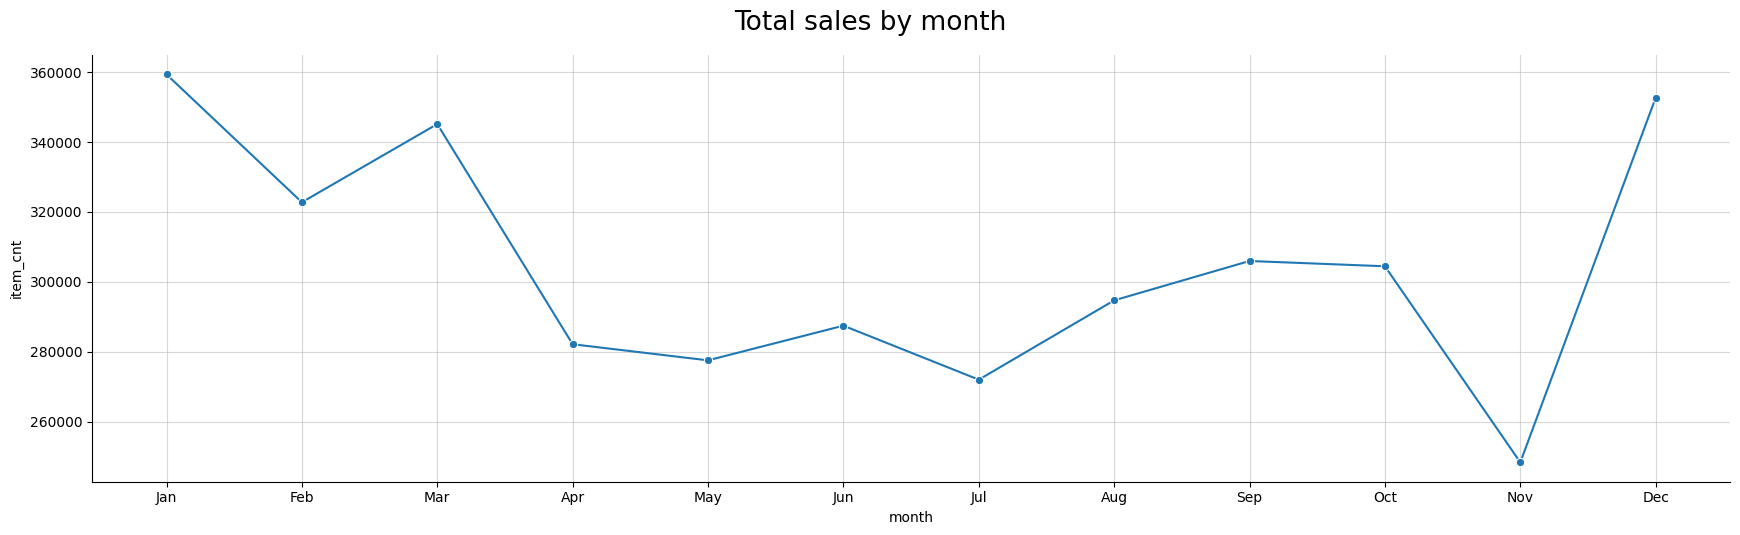

In [30]:
g = sns.relplot(
    data=gp_month_sum,
    x='month',
    y='item_cnt',
    kind='line',
    aspect=3.5,
    marker='o'
);

g.figure.suptitle('Total sales by month', y=1.06, fontsize=19)
g.set(xticks=range(12), xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.5) 


In [31]:
gp_month_mean = train_monthly.groupby(['month'], as_index=False)['item_cnt'].mean()


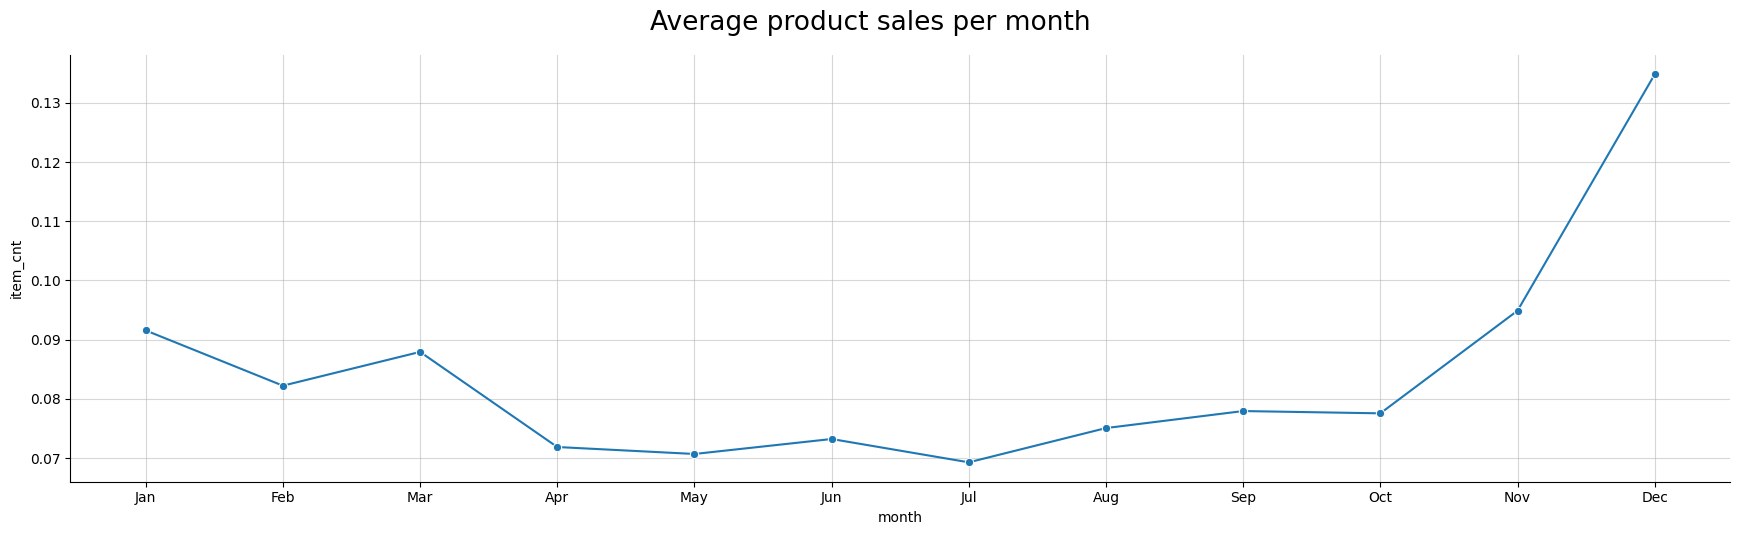

In [32]:
g = sns.relplot(
    data=gp_month_mean,
    x='month',
    y='item_cnt',
    kind='line',
    aspect=3.5,
    marker='o'
);
g.figure.suptitle('Average product sales per month', y=1.06, fontsize=19)
g.set(xticks=range(12), xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.5) 


In [33]:
gp_month_shop_sum = train_monthly.groupby(['month', 'shop_id'], as_index=False)['item_cnt'].sum()
gp_month_shop_mean = train_monthly.groupby(['month', 'shop_id'], as_index=False)['item_cnt'].mean()

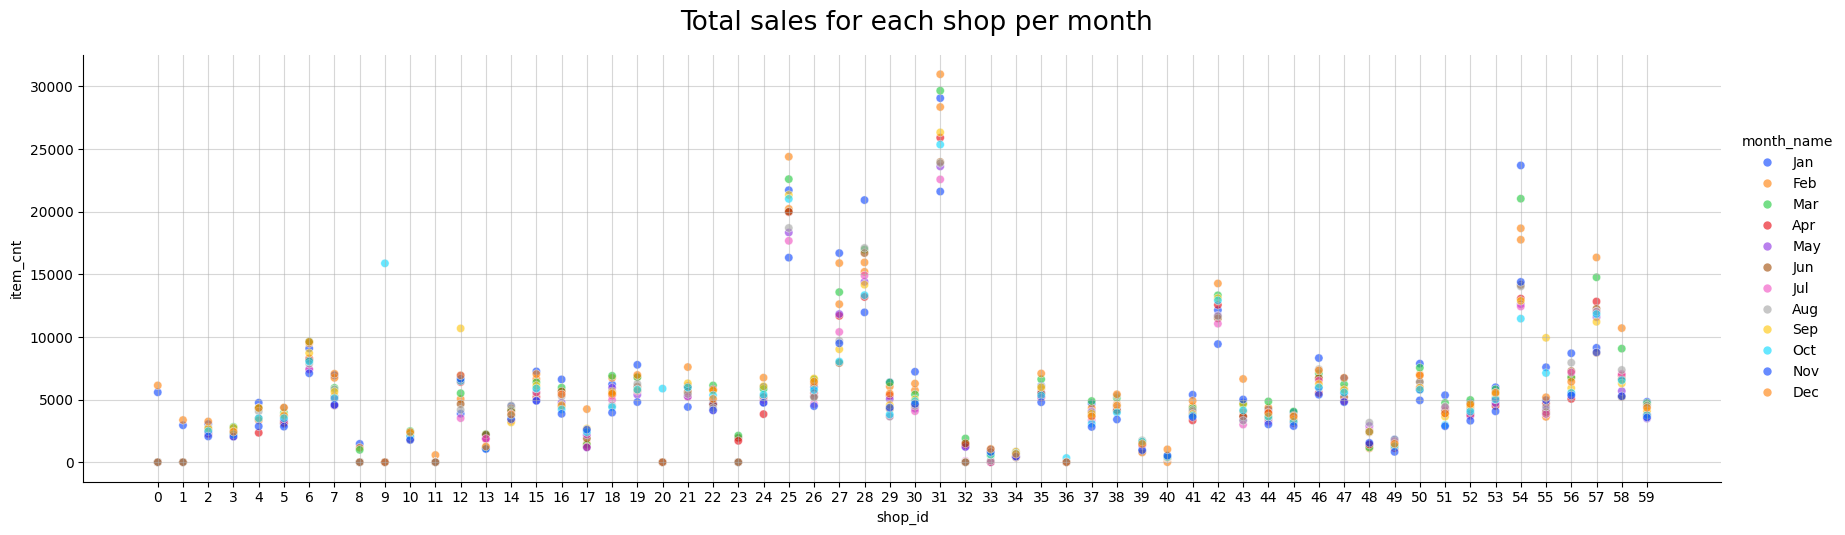

In [34]:
month_names = {
    0: 'Jan', 1: 'Feb', 2: 'Mar', 3: 'Apr', 4: 'May', 5: 'Jun', 
    6: 'Jul', 7: 'Aug', 8: 'Sep', 9: 'Oct', 10: 'Nov', 11: 'Dec'
}

gp_month_shop_sum['month_name'] = gp_month_shop_sum['month'].map(month_names)

g = sns.relplot(
    data=gp_month_shop_sum,
    x='shop_id',
    y='item_cnt',
    kind='scatter',
    hue="month_name",
    hue_order=list(month_names.values()),
    palette="bright",
    aspect=3.5,
    marker='o',
    alpha=0.6
);
g.figure.suptitle('Total sales for each shop per month', y=1.06, fontsize=19)
g.set(xticks=range(60))
plt.grid(True, alpha=0.5) 


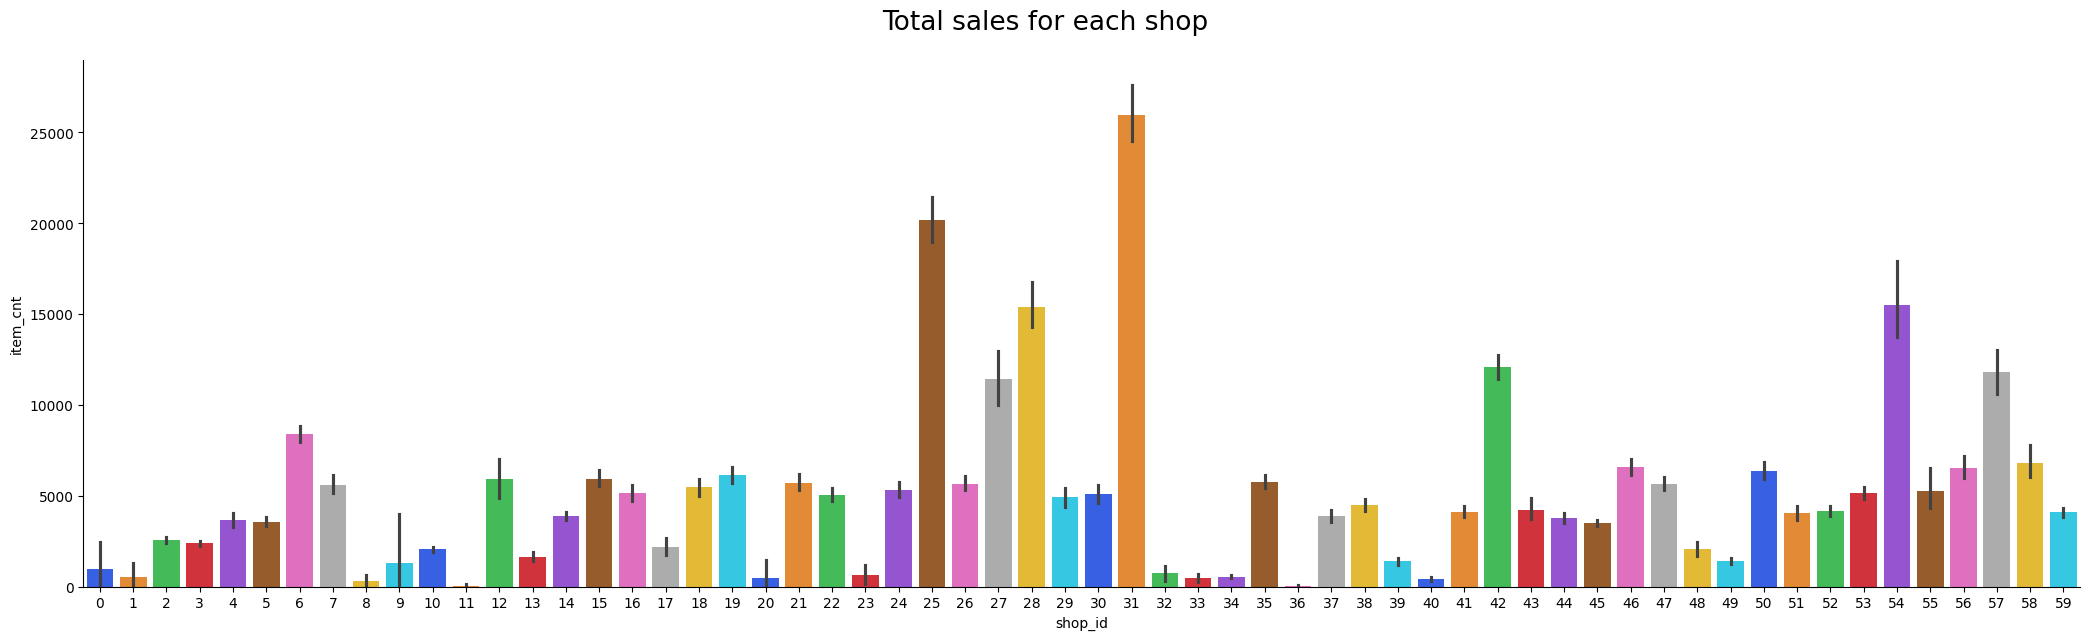

In [35]:
g = sns.catplot(
    data=gp_month_shop_sum,
    x='shop_id',
    y='item_cnt',
    hue="shop_id",
    legend=False,
    palette="bright",
    aspect=3.5,
    height=6,
    kind="bar",
    alpha=0.9
);
g.figure.suptitle('Total sales for each shop', y=1.06, fontsize=19);



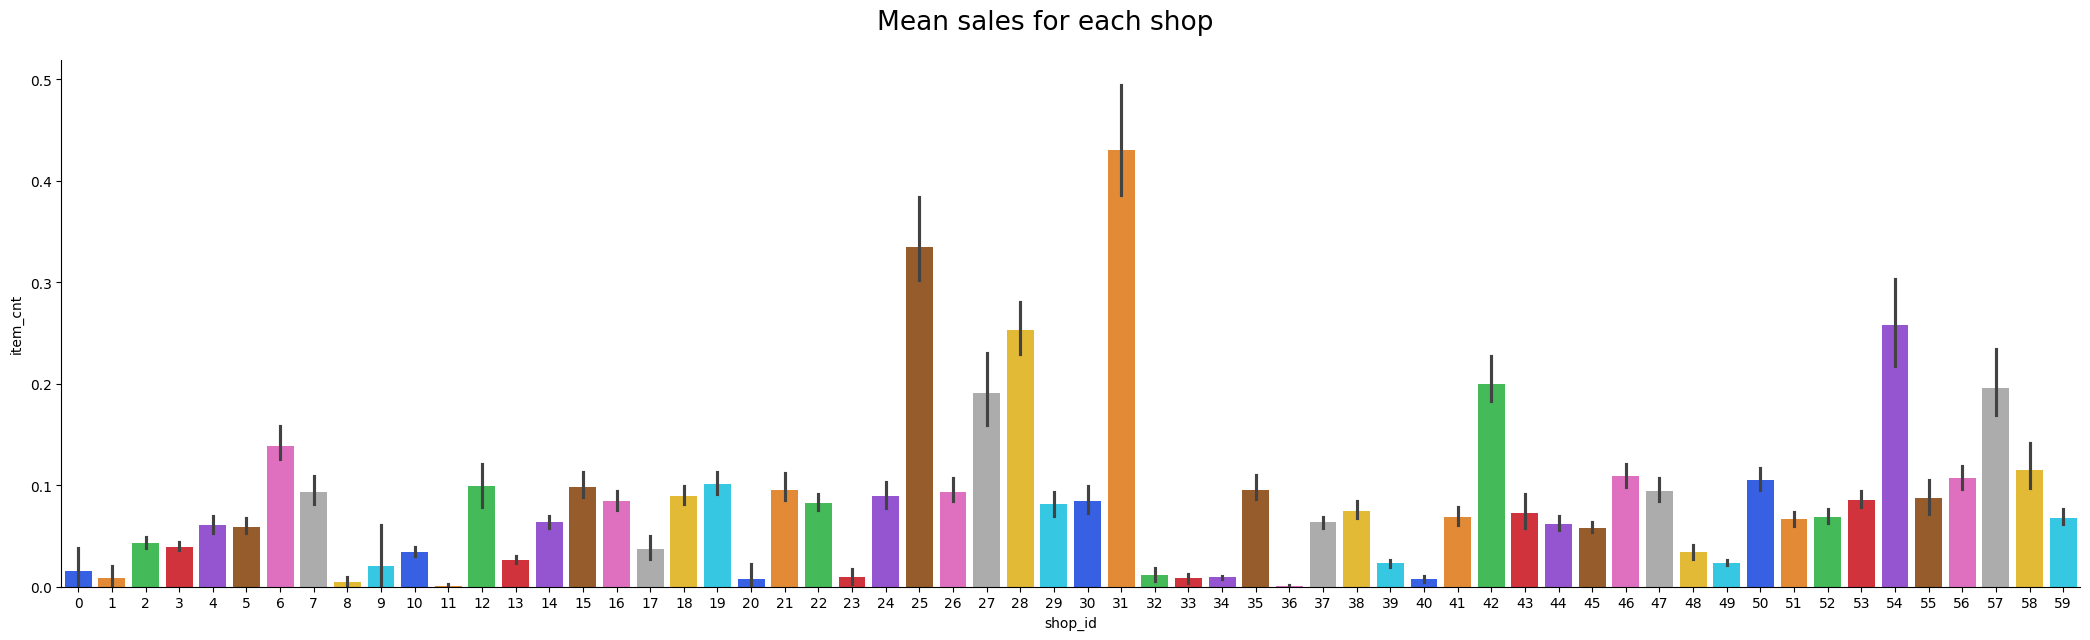

In [36]:
g = sns.catplot(
    data=gp_month_shop_mean,
    x='shop_id',
    y='item_cnt',
    hue="shop_id",
    legend=False,
    palette="bright",
    aspect=3.5,
    height=6,
    kind="bar",
    alpha=0.9
);
g.figure.suptitle('Mean sales for each shop', y=1.06, fontsize=19);

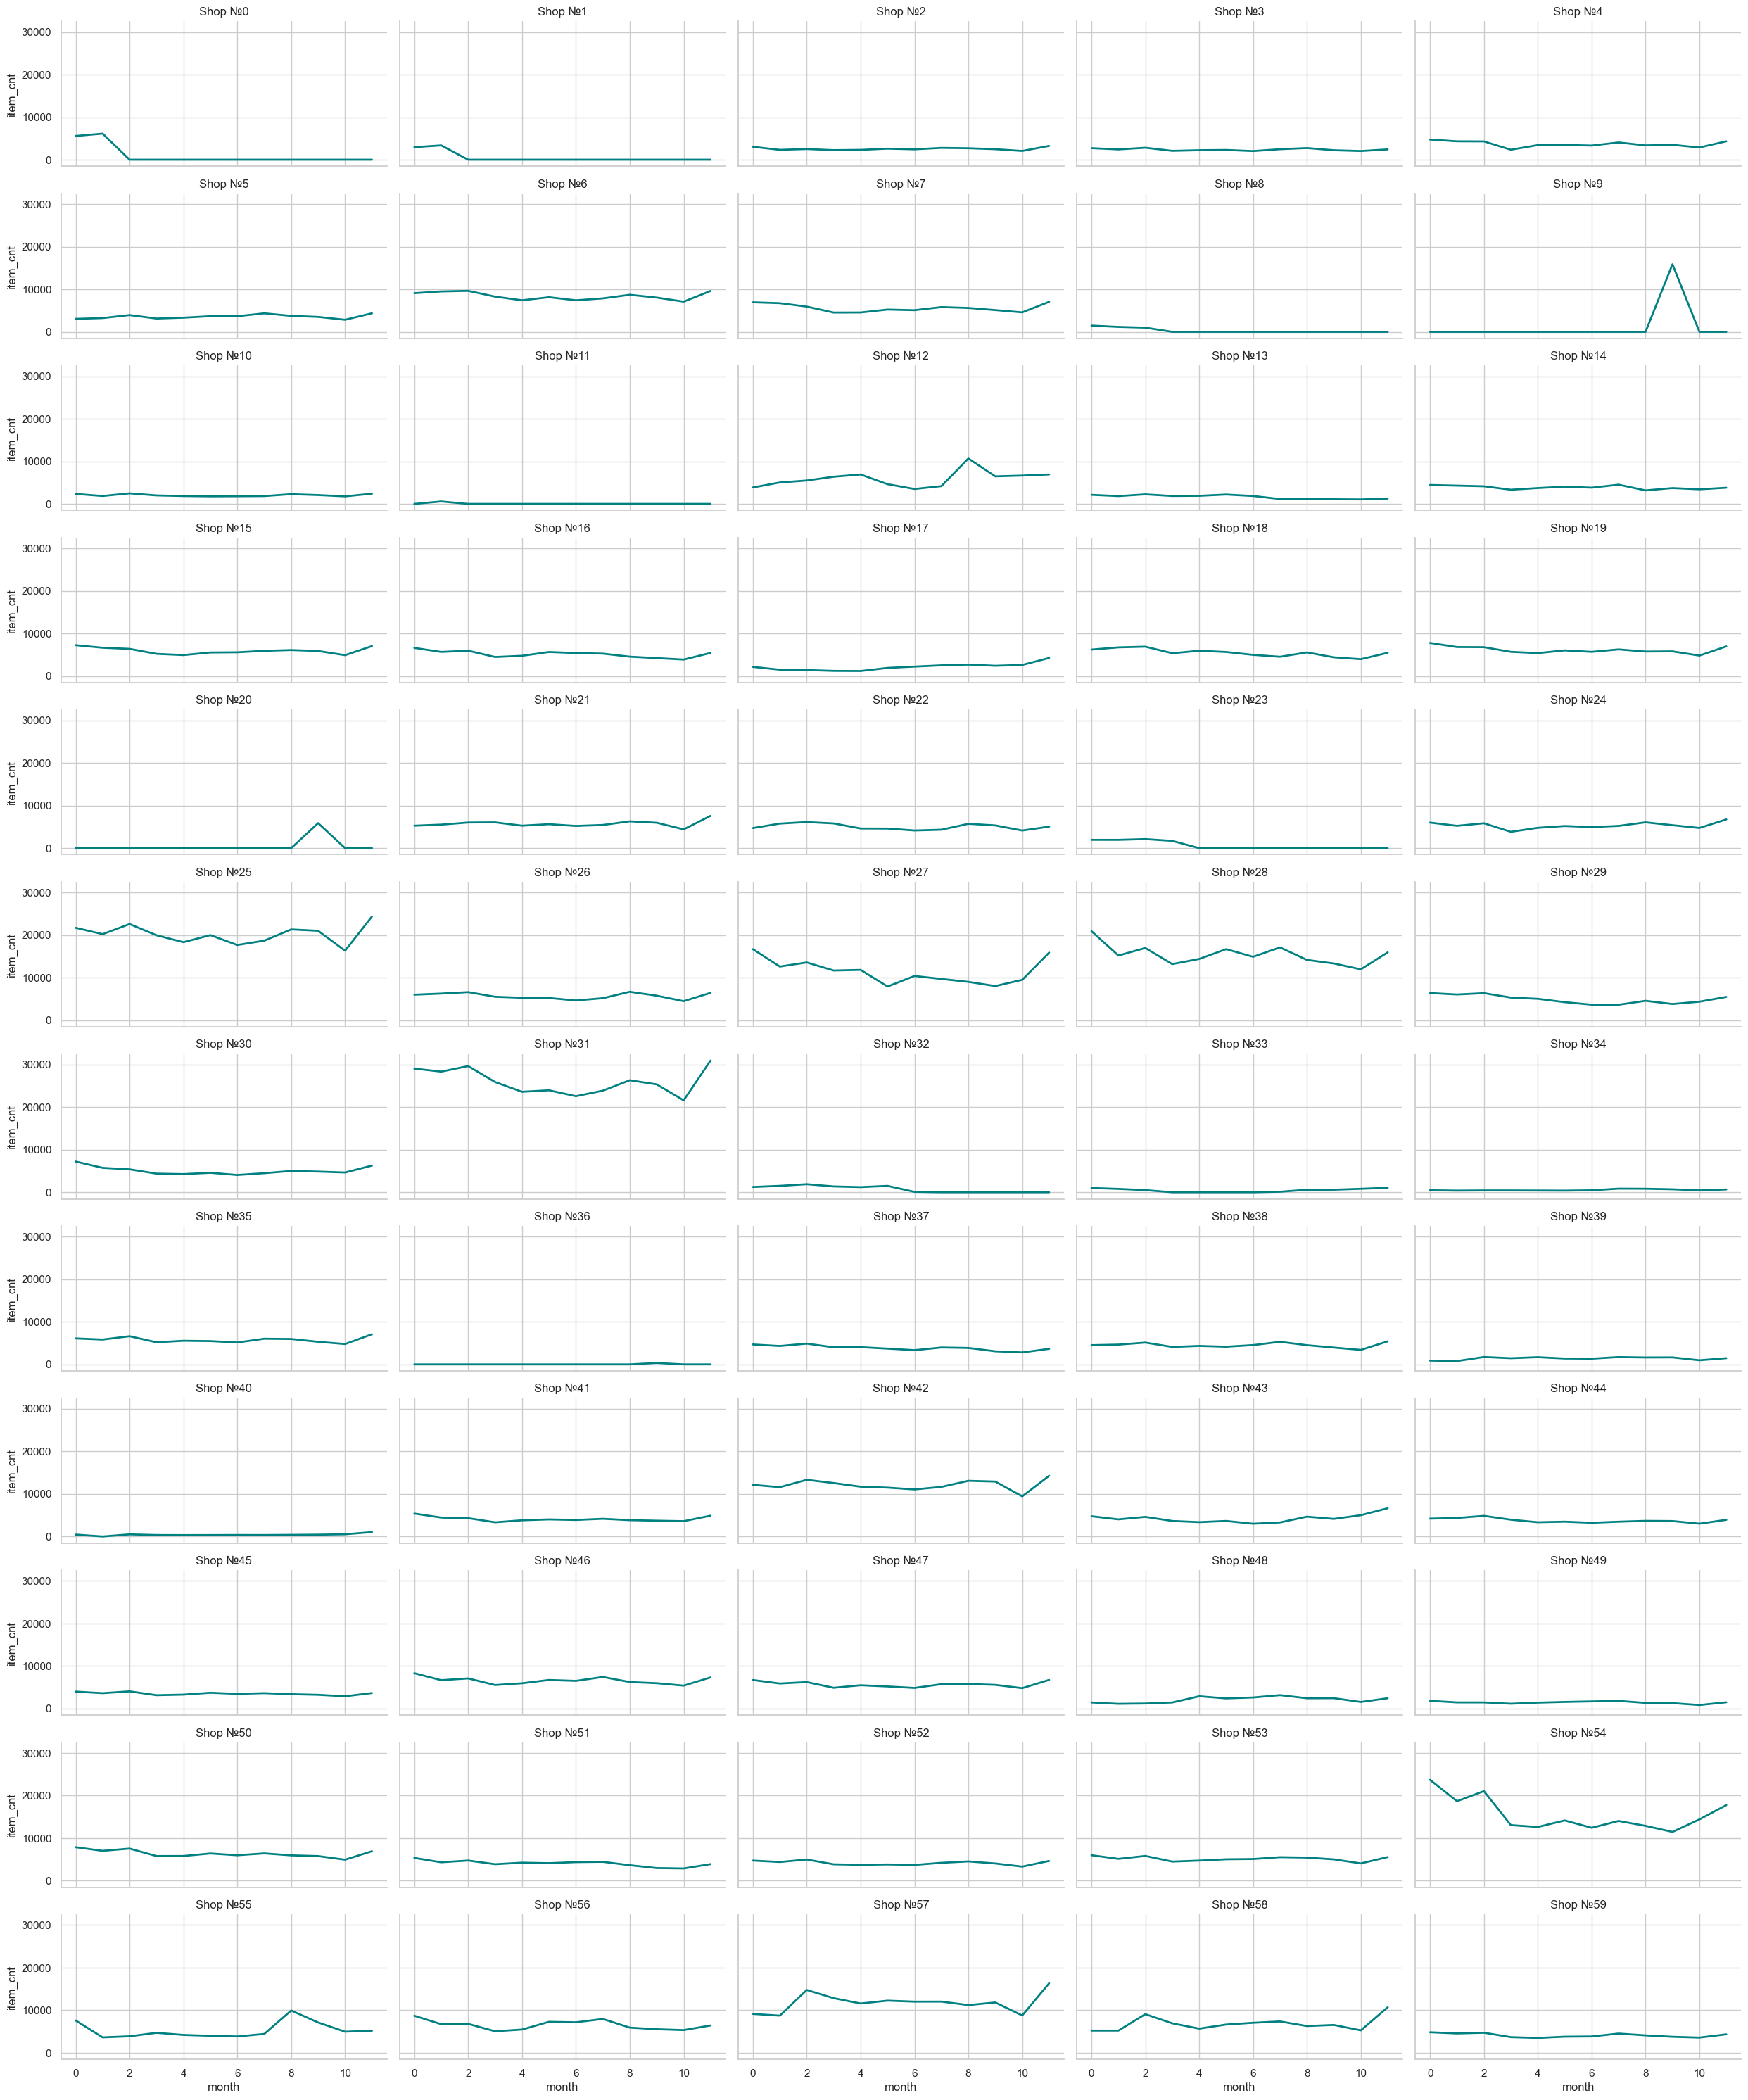

In [ ]:
g = sns.relplot(
    data=gp_month_shop_sum,
    x='month',
    y='item_cnt',
    kind='line',
    col='shop_id',     
    col_wrap=5,        
    height=2.5,        
    aspect=2,        
    linewidth=2,
    color='teal'
)
g.figure.suptitle('')
g.set_titles(col_template="Shop №{col_name}")

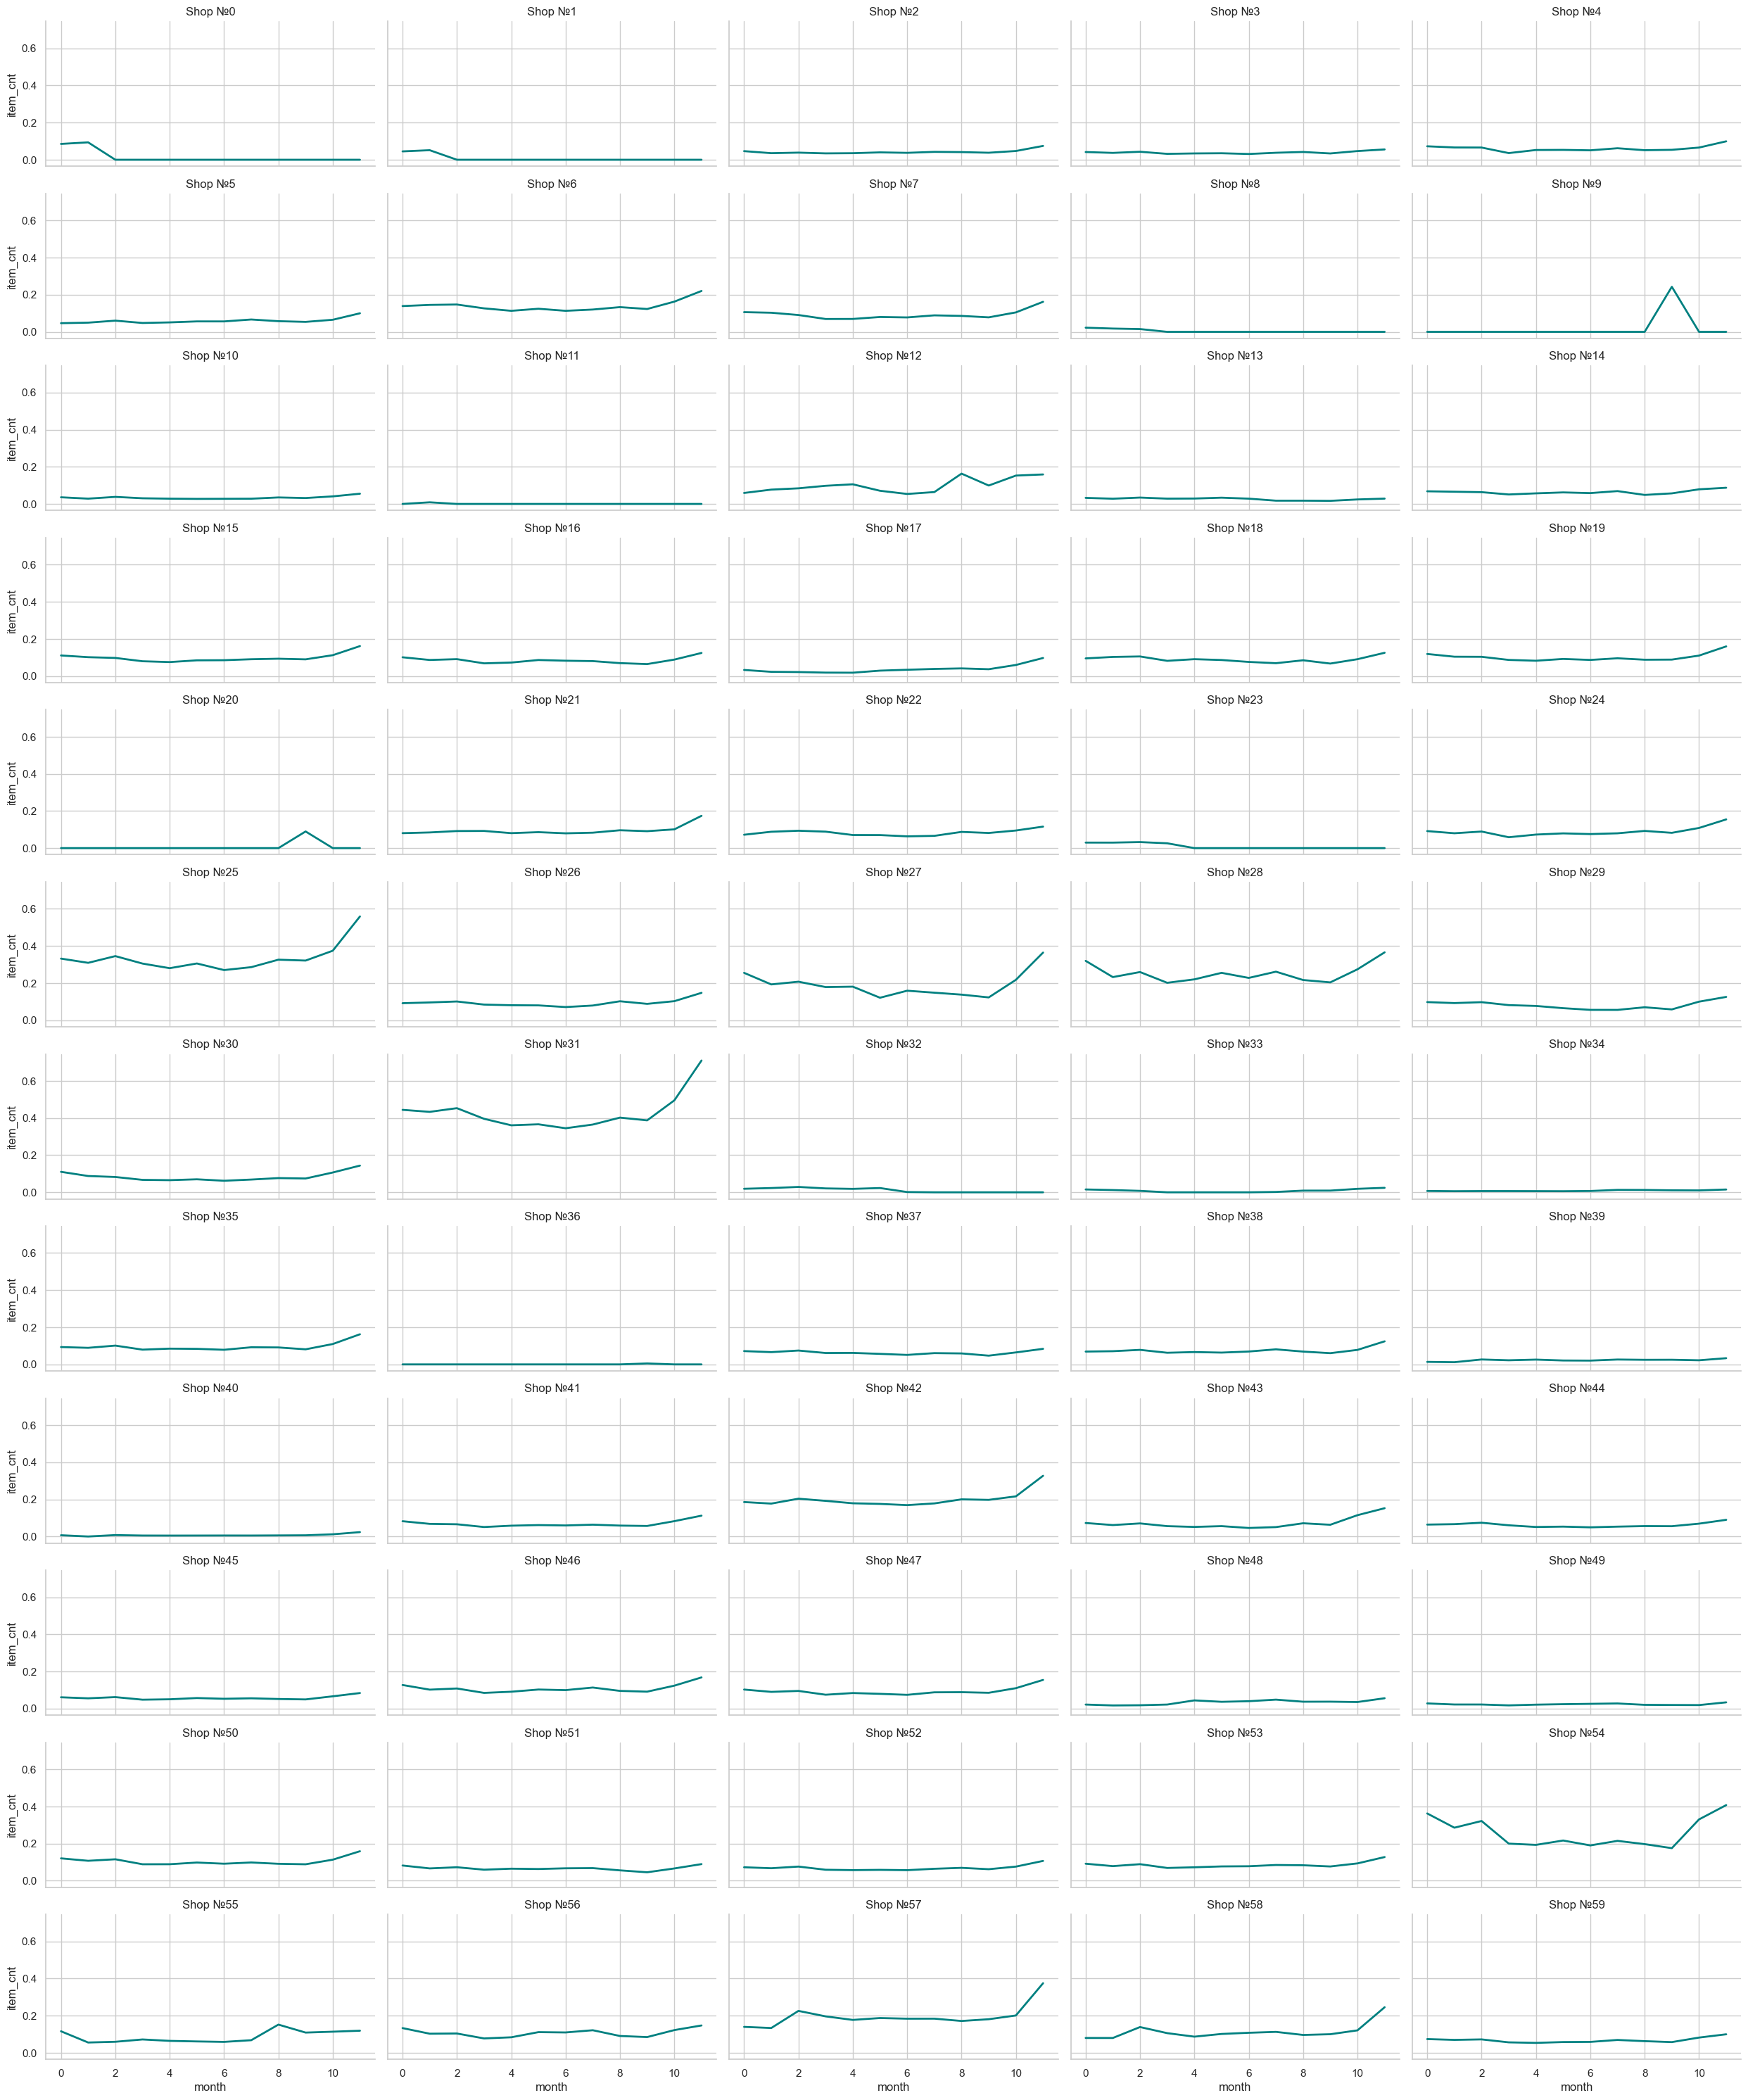

In [65]:
g = sns.relplot(
    data=gp_month_shop_mean,
    x='month',
    y='item_cnt',
    kind='line',
    col='shop_id',     
    col_wrap=5,        
    height=2.5,        
    aspect=2,        
    linewidth=2,
    color='teal'
)
g.figure.suptitle('')
g.set_titles(col_template="Shop №{col_name}")

In [37]:
gp_category_month_sum = train_monthly.groupby(['month','item_category_id'], as_index=False)['item_cnt'].sum()
gp_category_month_mean = train_monthly.groupby(['month','item_category_id'], as_index=False)['item_cnt'].mean()

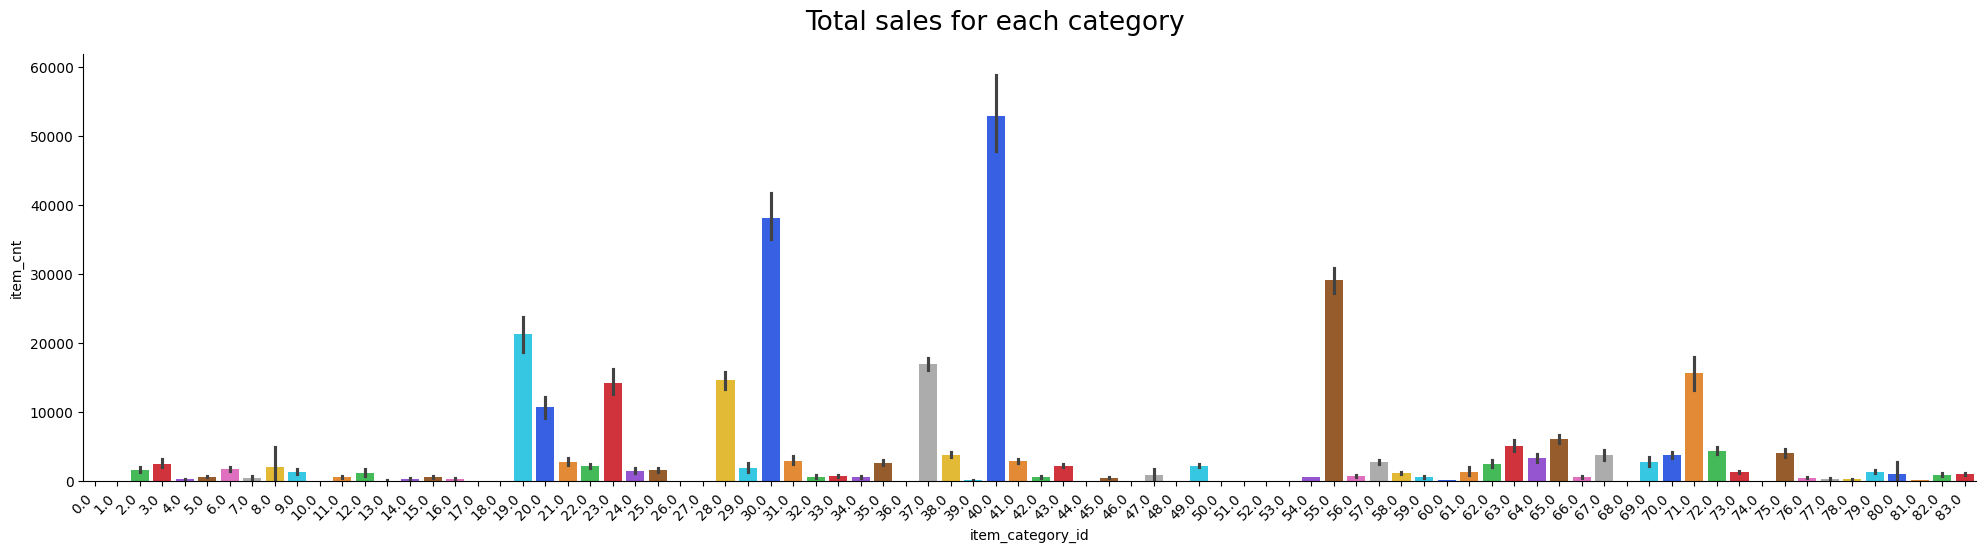

In [ ]:
g = sns.catplot(
    data=gp_category_month_sum,
    x='item_category_id',
    y='item_cnt',
    aspect=4,
    hue='item_category_id',
    legend=False,
    palette="bright",
    kind="bar",
    alpha=0.9
).set_xticklabels(rotation=45, horizontalalignment="right");
g.figure.suptitle('Total sales for each category', y=1.06, fontsize=19);

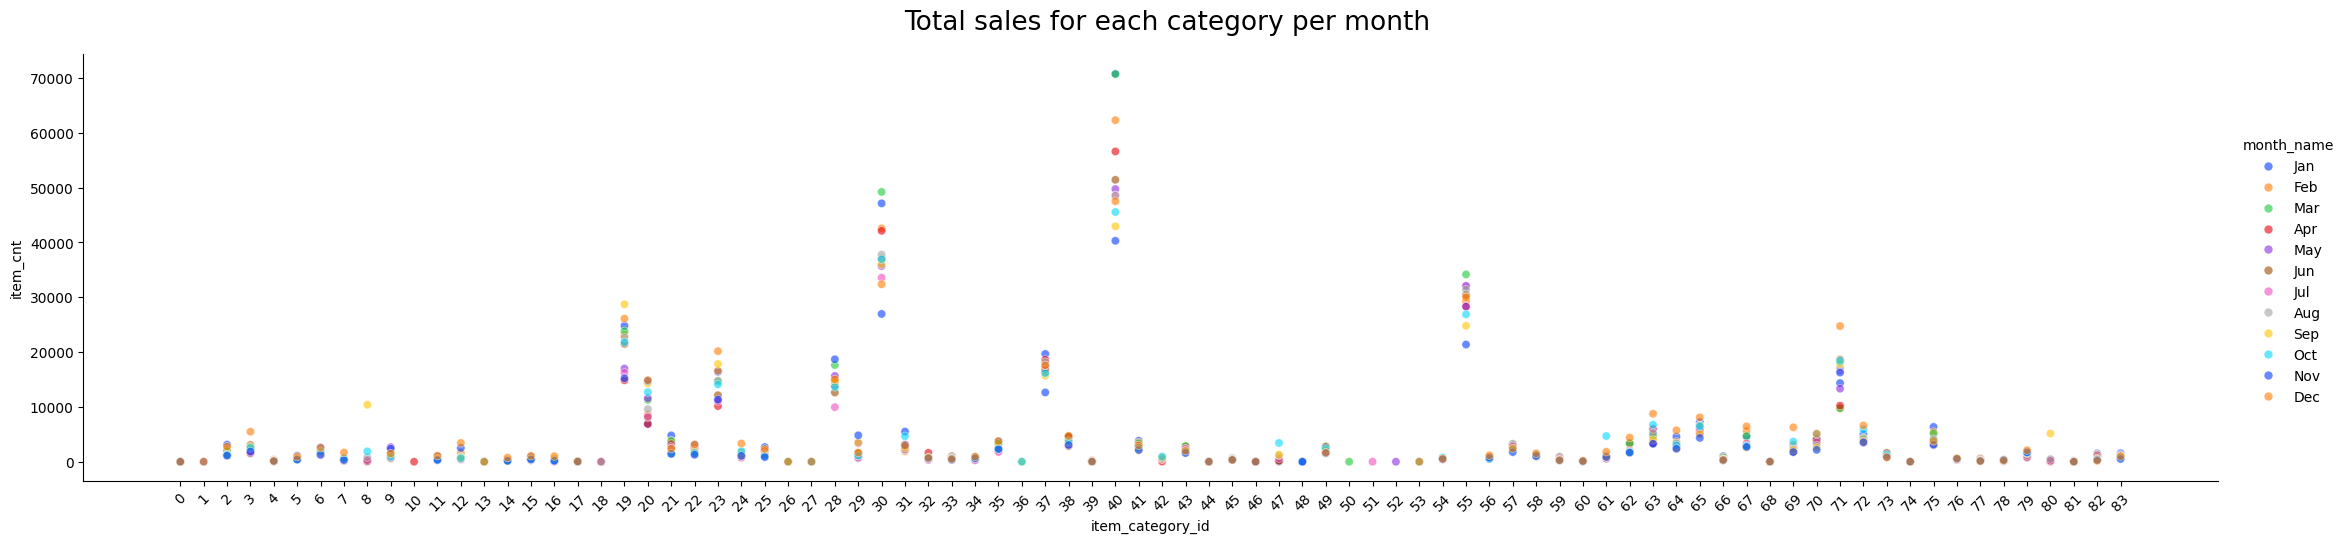

In [39]:
month_names = {
    0: 'Jan', 1: 'Feb', 2: 'Mar', 3: 'Apr', 4: 'May', 5: 'Jun', 
    6: 'Jul', 7: 'Aug', 8: 'Sep', 9: 'Oct', 10: 'Nov', 11: 'Dec'
}

gp_category_month_sum['month_name'] = gp_category_month_sum['month'].map(month_names)

g = sns.relplot(
    data=gp_category_month_sum,
    x='item_category_id',
    y='item_cnt',
    kind='scatter',
    hue="month_name",
    hue_order=list(month_names.values()),
    palette="bright",
    aspect=4.5,
    marker='o',
    alpha=0.6
);
g.figure.suptitle('Total sales for each category per month', y=1.06, fontsize=19)
g.set(xticks=range(84))
g.set_xticklabels(rotation=45,  step=1);



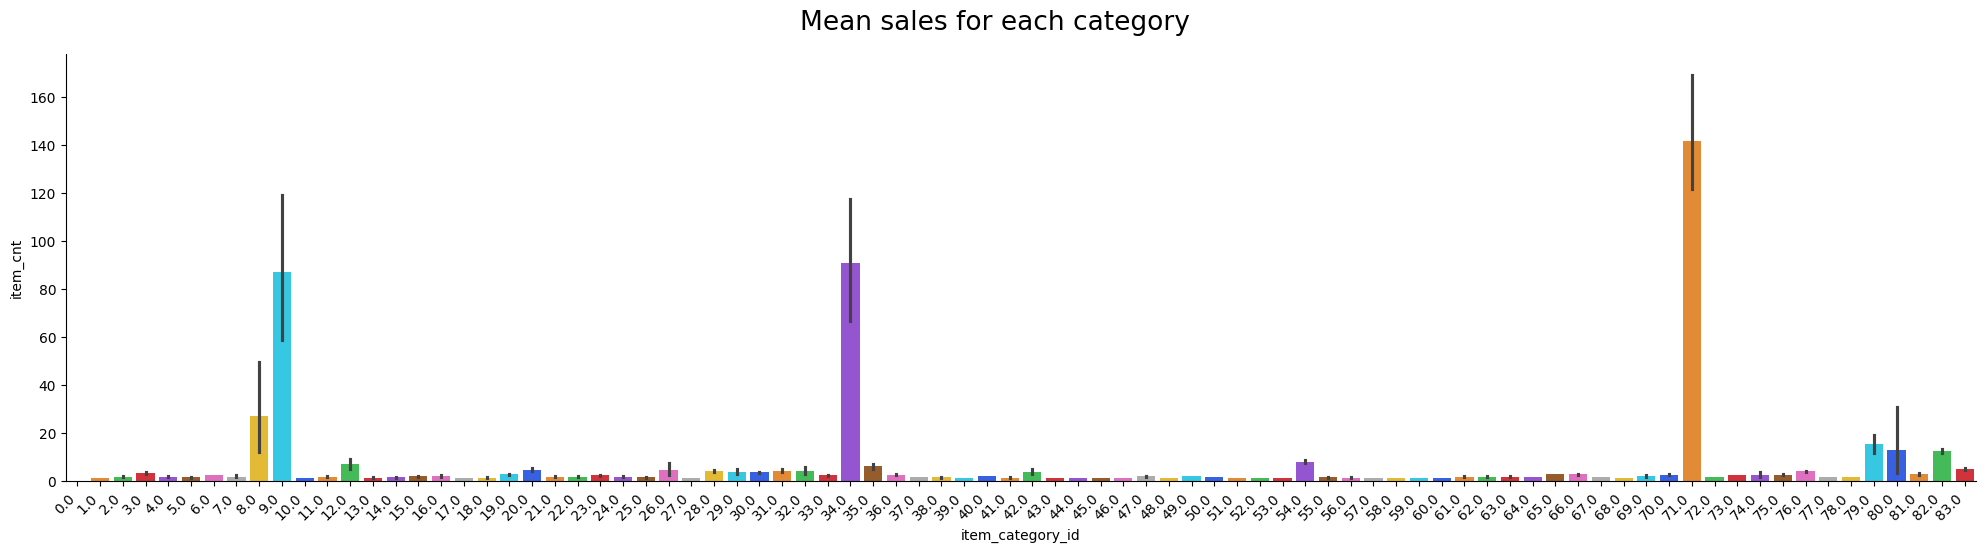

In [40]:
g = sns.catplot(
    data=gp_category_month_mean,
    x='item_category_id',
    y='item_cnt',
    aspect=4,
    hue='item_category_id',
    legend=False,
    palette="bright",
    kind="bar",
    alpha=0.9
).set_xticklabels(rotation=45, horizontalalignment="right");
g.figure.suptitle('Mean sales for each category', y=1.06, fontsize=19);

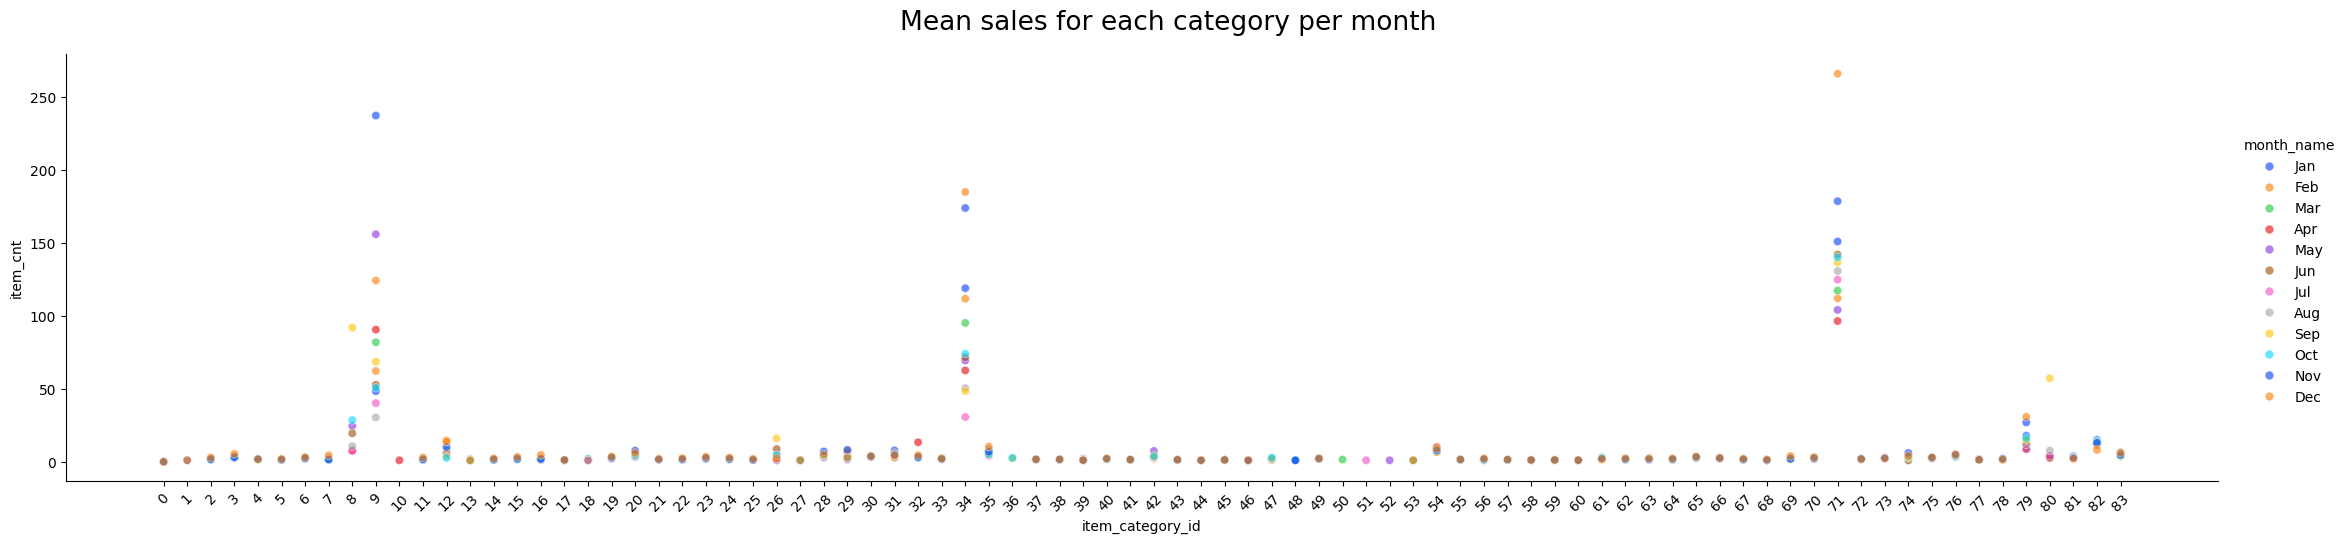

In [41]:
month_names = {
    0: 'Jan', 1: 'Feb', 2: 'Mar', 3: 'Apr', 4: 'May', 5: 'Jun', 
    6: 'Jul', 7: 'Aug', 8: 'Sep', 9: 'Oct', 10: 'Nov', 11: 'Dec'
}

gp_category_month_mean['month_name'] = gp_category_month_mean['month'].map(month_names)

g = sns.relplot(
    data=gp_category_month_mean,
    x='item_category_id',
    y='item_cnt',
    kind='scatter',
    hue="month_name",
    hue_order=list(month_names.values()),
    palette="bright",
    aspect=4.5,
    marker='o',
    alpha=0.6
);
g.figure.suptitle('Mean sales for each category per month', y=1.06, fontsize=19)
g.set(xticks=range(84))
g.set_xticklabels(rotation=45,  step=1);



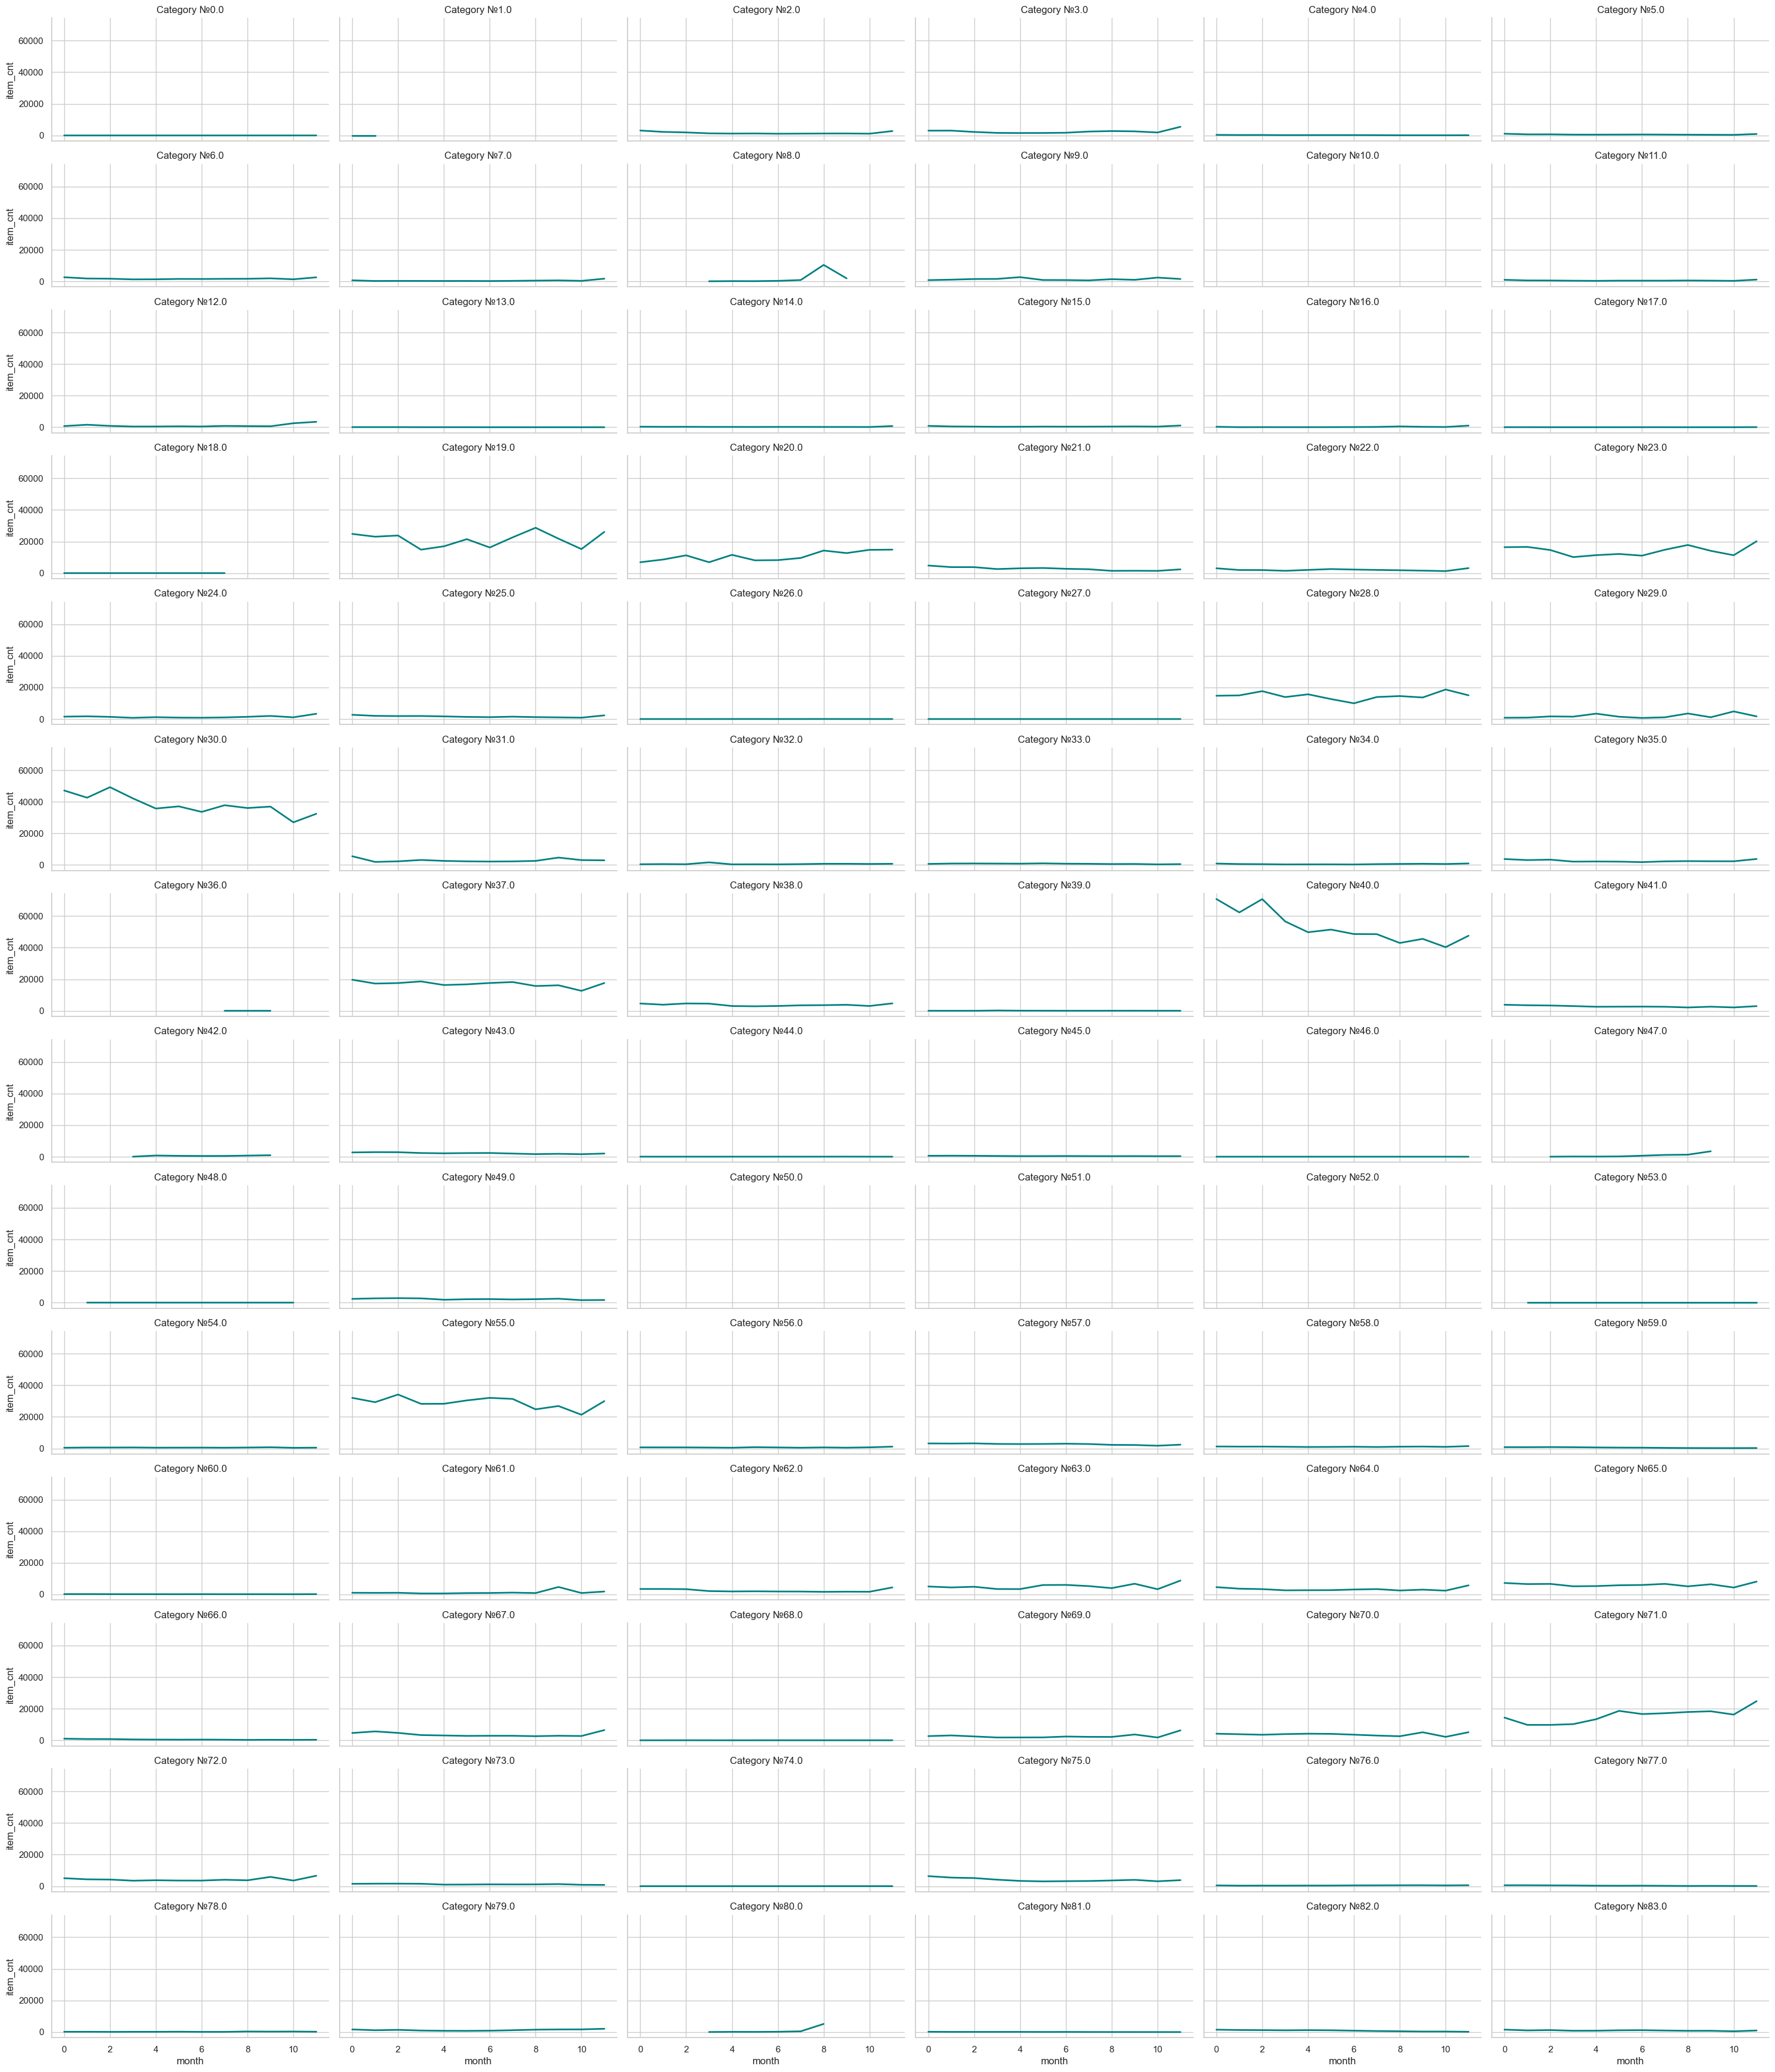

In [ ]:
g = sns.relplot(
    data=gp_category_month_sum,
    x='month',
    y='item_cnt',
    kind='line',
    col='item_category_id',     
    col_wrap=6,        
    height=2.5,        
    aspect=2,        
    linewidth=2,
    color='teal'
);
g.figure.suptitle('')
g.set_titles(col_template="Category №{col_name}")



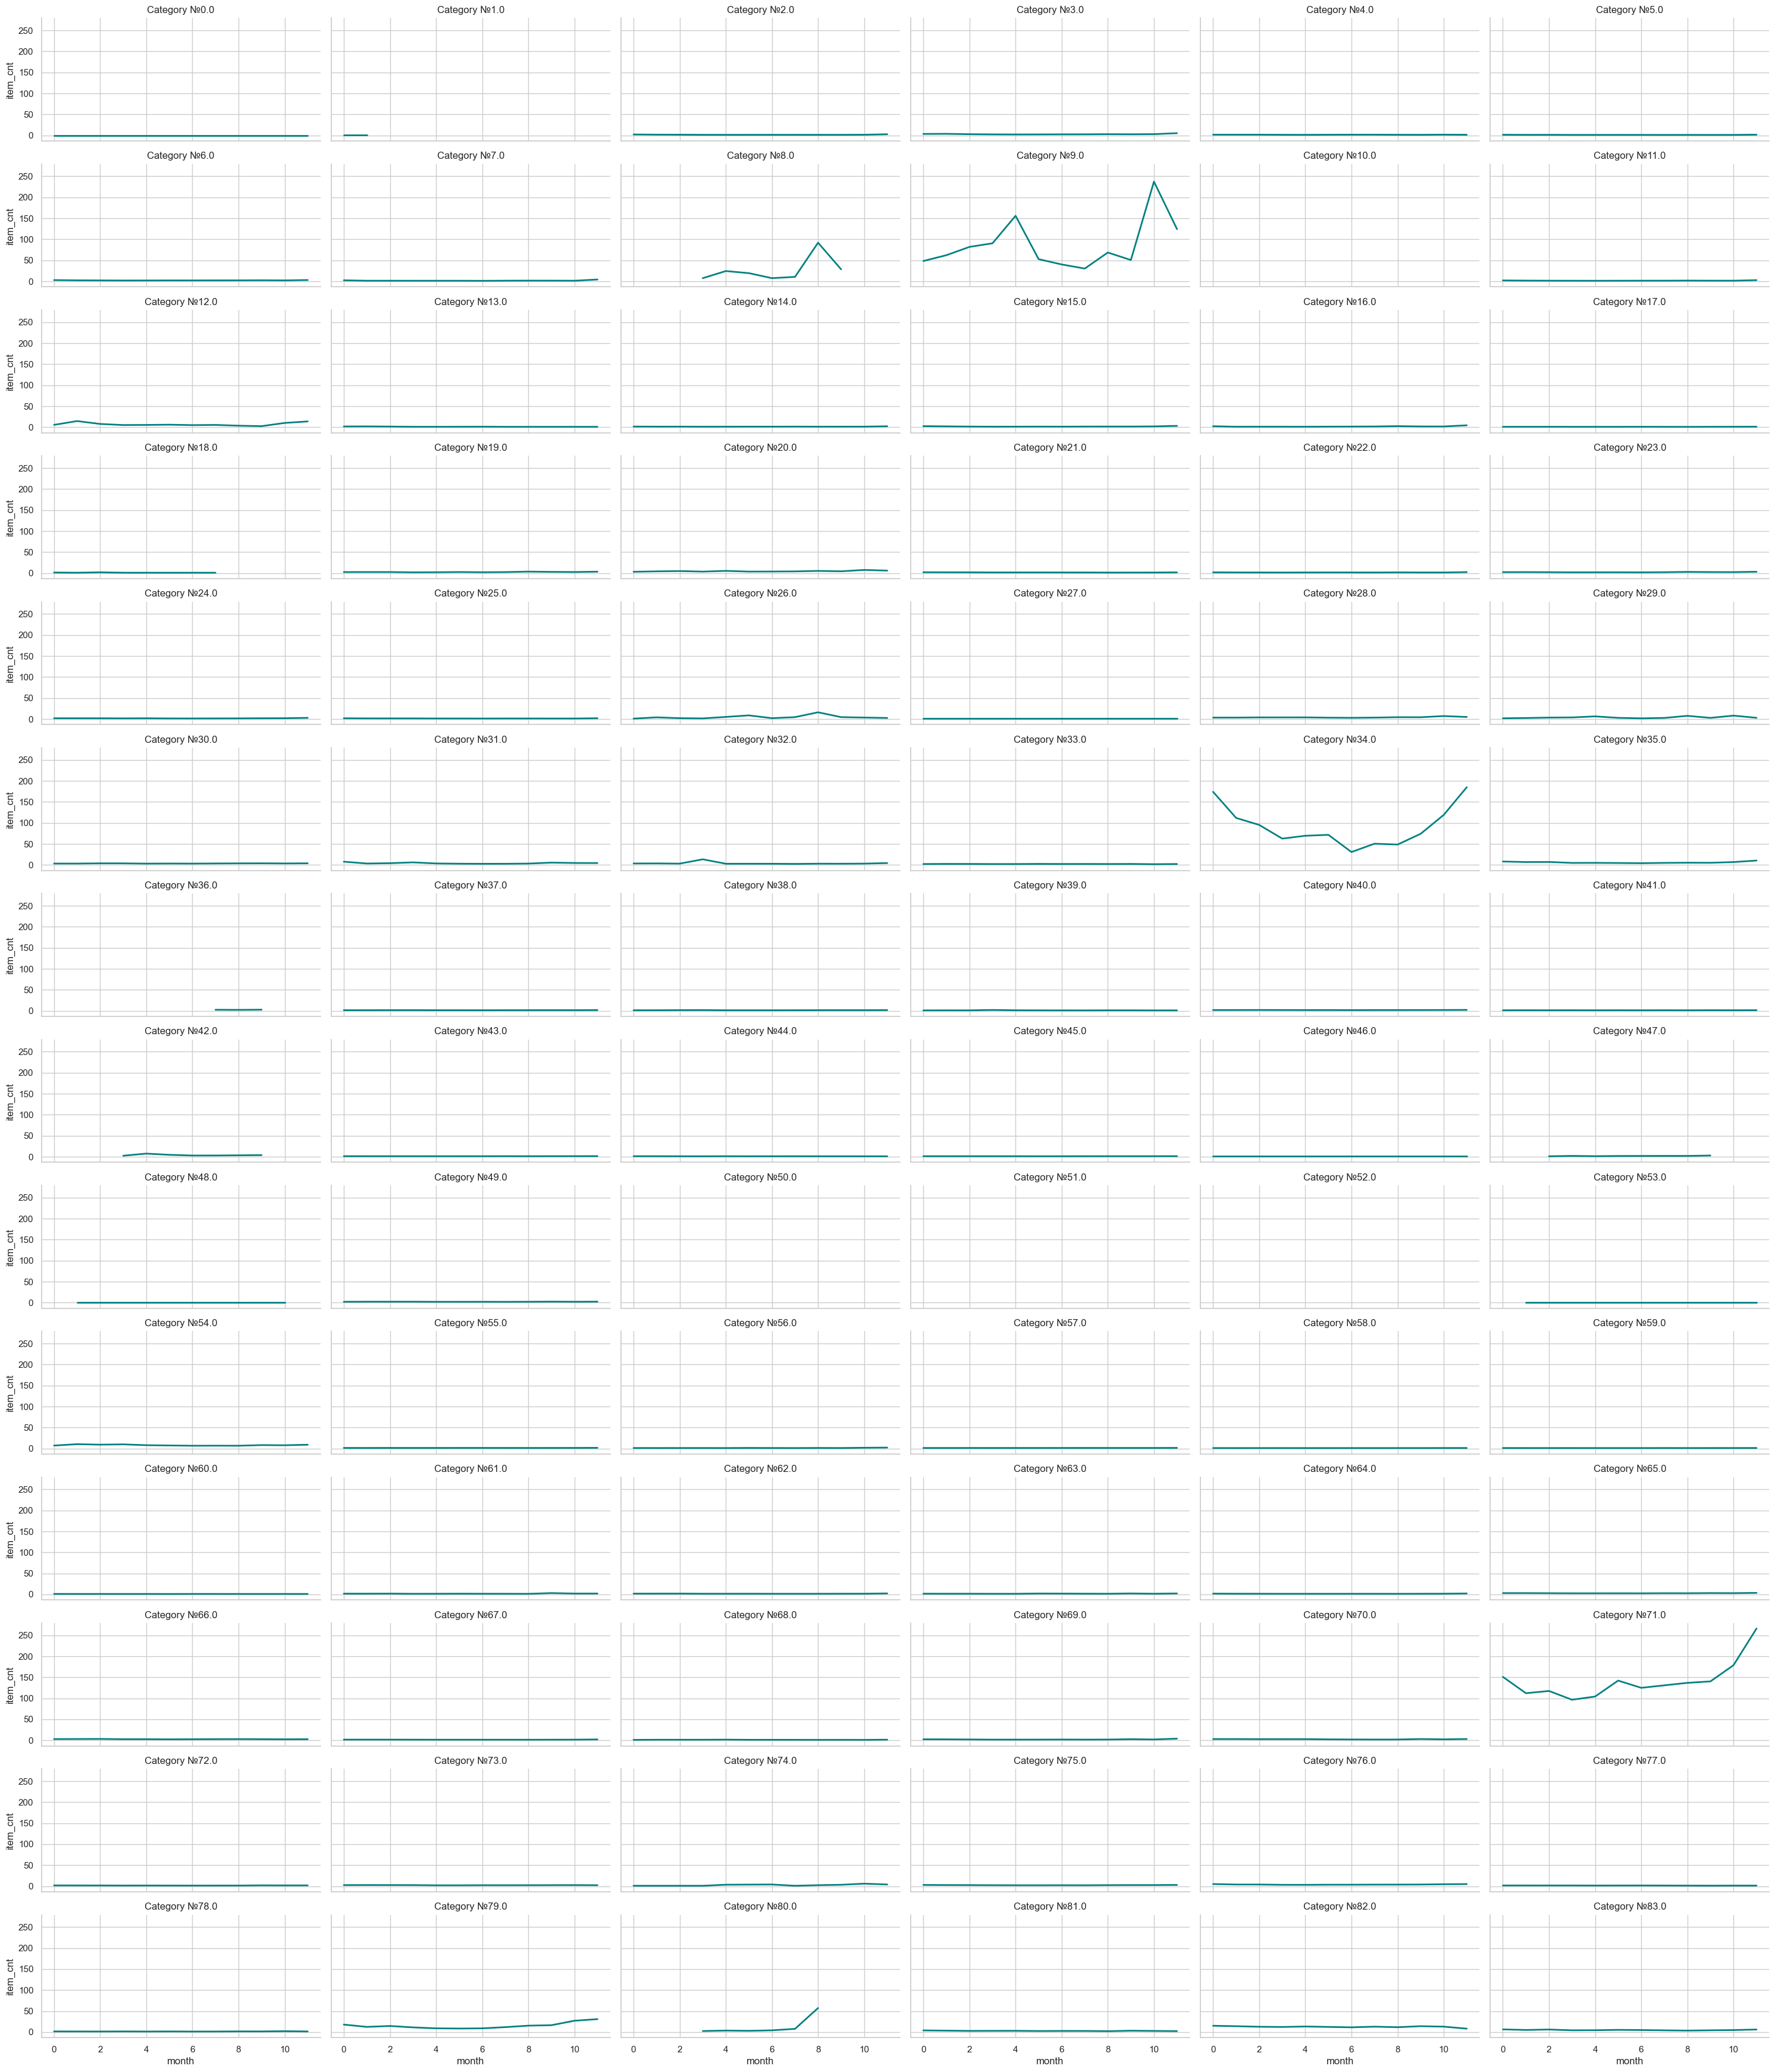

In [69]:
g = sns.relplot(
    data=gp_category_month_mean,
    x='month',
    y='item_cnt',
    kind='line',
    col='item_category_id',     
    col_wrap=6,        
    height=2.5,        
    aspect=2,        
    linewidth=2,
    color='teal'
);
g.figure.suptitle('')
g.set_titles(col_template="Category №{col_name}")



видим что для магазинов и критериев , некоторые сильно выделяются , можно сделать признак , который будет по бинам разбивать магазиын и критерии , чтобы обозначать какого он уровня

In [42]:
gp_category_transaction = train_monthly.groupby(['item_category_id'], as_index=False).agg({
                                                                    'transaction': 'sum',
                                                                    'item_price_mean': 'mean',
                                                                    'revenue': 'sum'                                               
                                                                     })

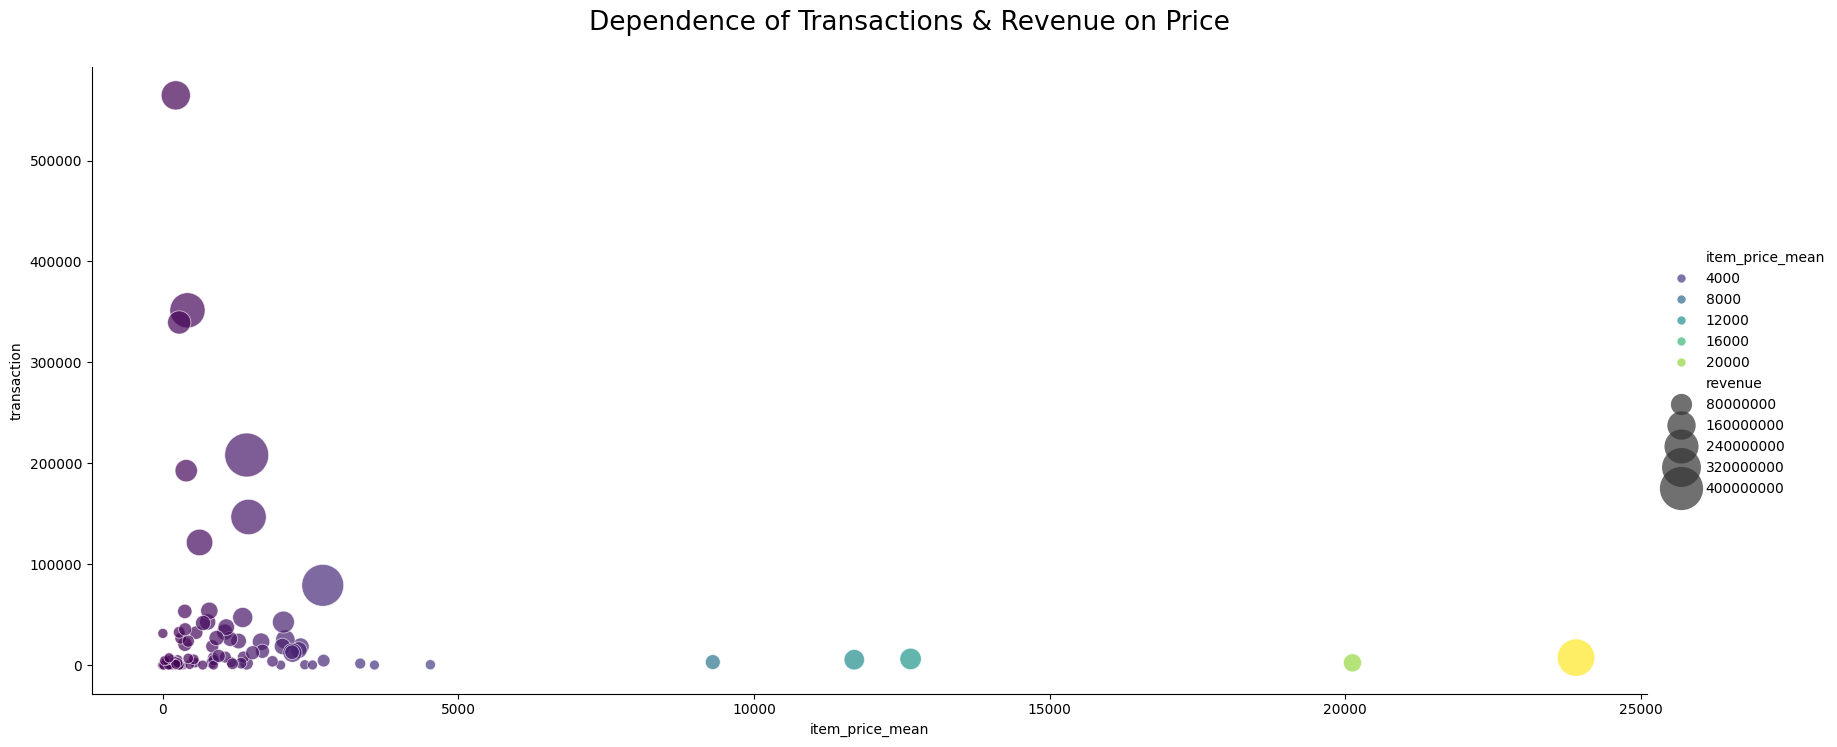

In [43]:
g = sns.relplot(
    data=gp_category_transaction,
    x='item_price_mean',
    y='transaction',
    size='revenue',         
    hue='item_price_mean',       
    palette='viridis',      
    sizes=(50, 1000),       
    alpha=0.7,              
    aspect=2.4,
    height=7,  
);
g.figure.suptitle('Dependence of Transactions & Revenue on Price', y=1.06, fontsize=19);

In [44]:
gp_category_revenue= train_monthly.groupby(['item_category_id'], as_index=False).agg({
                                                                    'item_cnt': 'sum',
                                                                    'item_price_mean': 'mean',
                                                                    'revenue': 'sum'                                               
                                                                     })

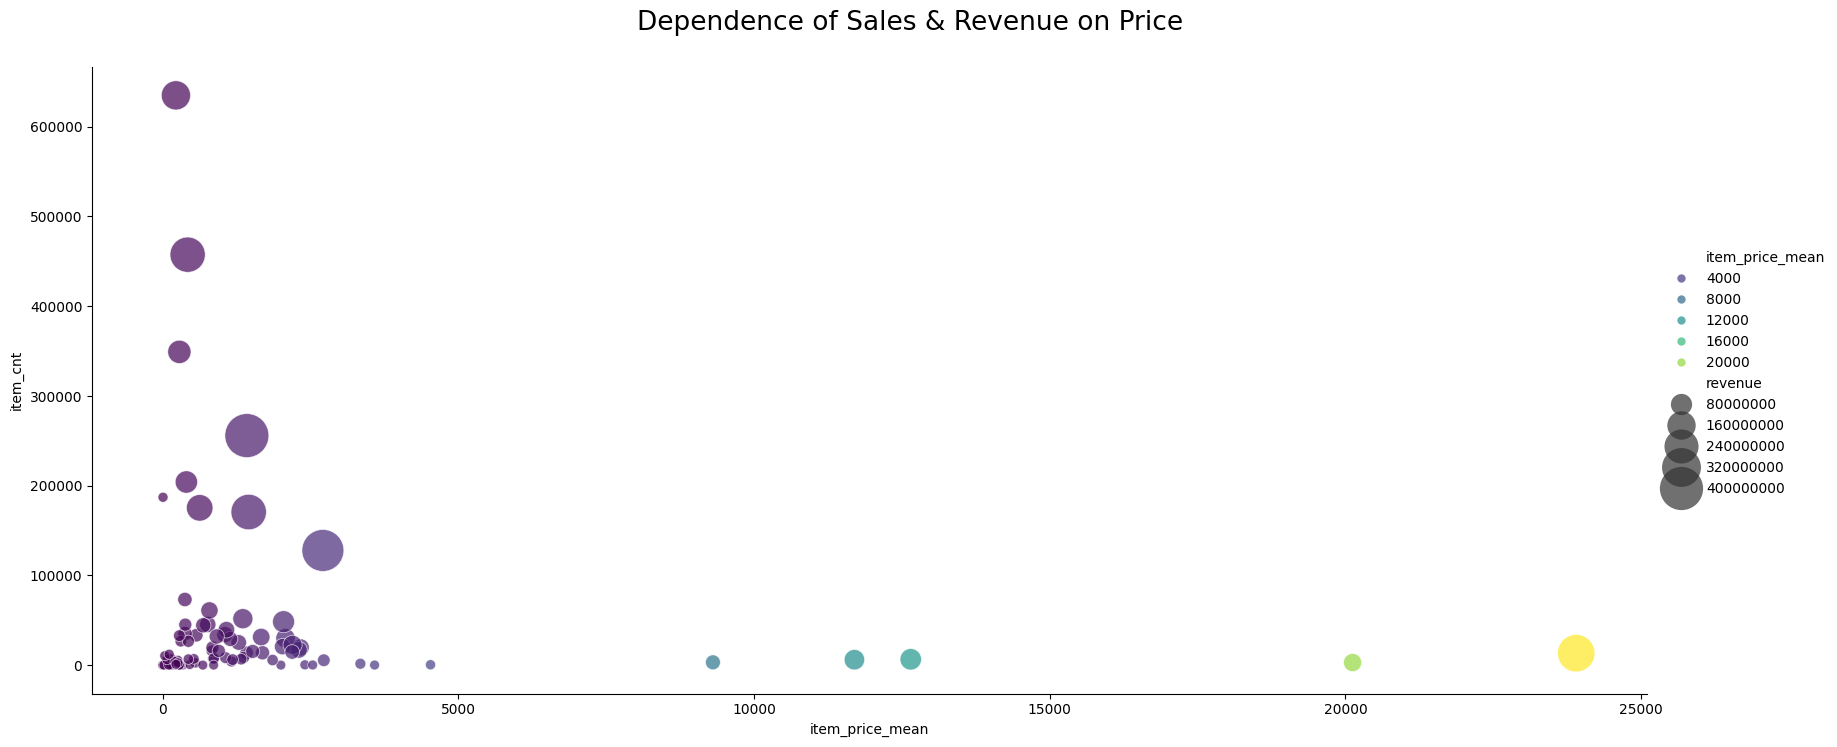

In [45]:
g = sns.relplot(
    data=gp_category_revenue,
    x='item_price_mean',
    y='item_cnt',
    size='revenue',         
    hue='item_price_mean',       
    palette='viridis',      
    sizes=(50, 1000),       
    alpha=0.7,              
    aspect=2.4,
    height=7,  
);
g.figure.suptitle('Dependence of Sales & Revenue on Price', y=1.06, fontsize=19);


In [46]:
gp_revenue= train_monthly.groupby(['month', 'shop_id', 'item_category_id'], as_index=False).agg({
                                                                    'item_cnt': 'sum',
                                                                    'item_price_mean': 'mean',
                                                                    'revenue': 'sum'                                               
                                                                     })

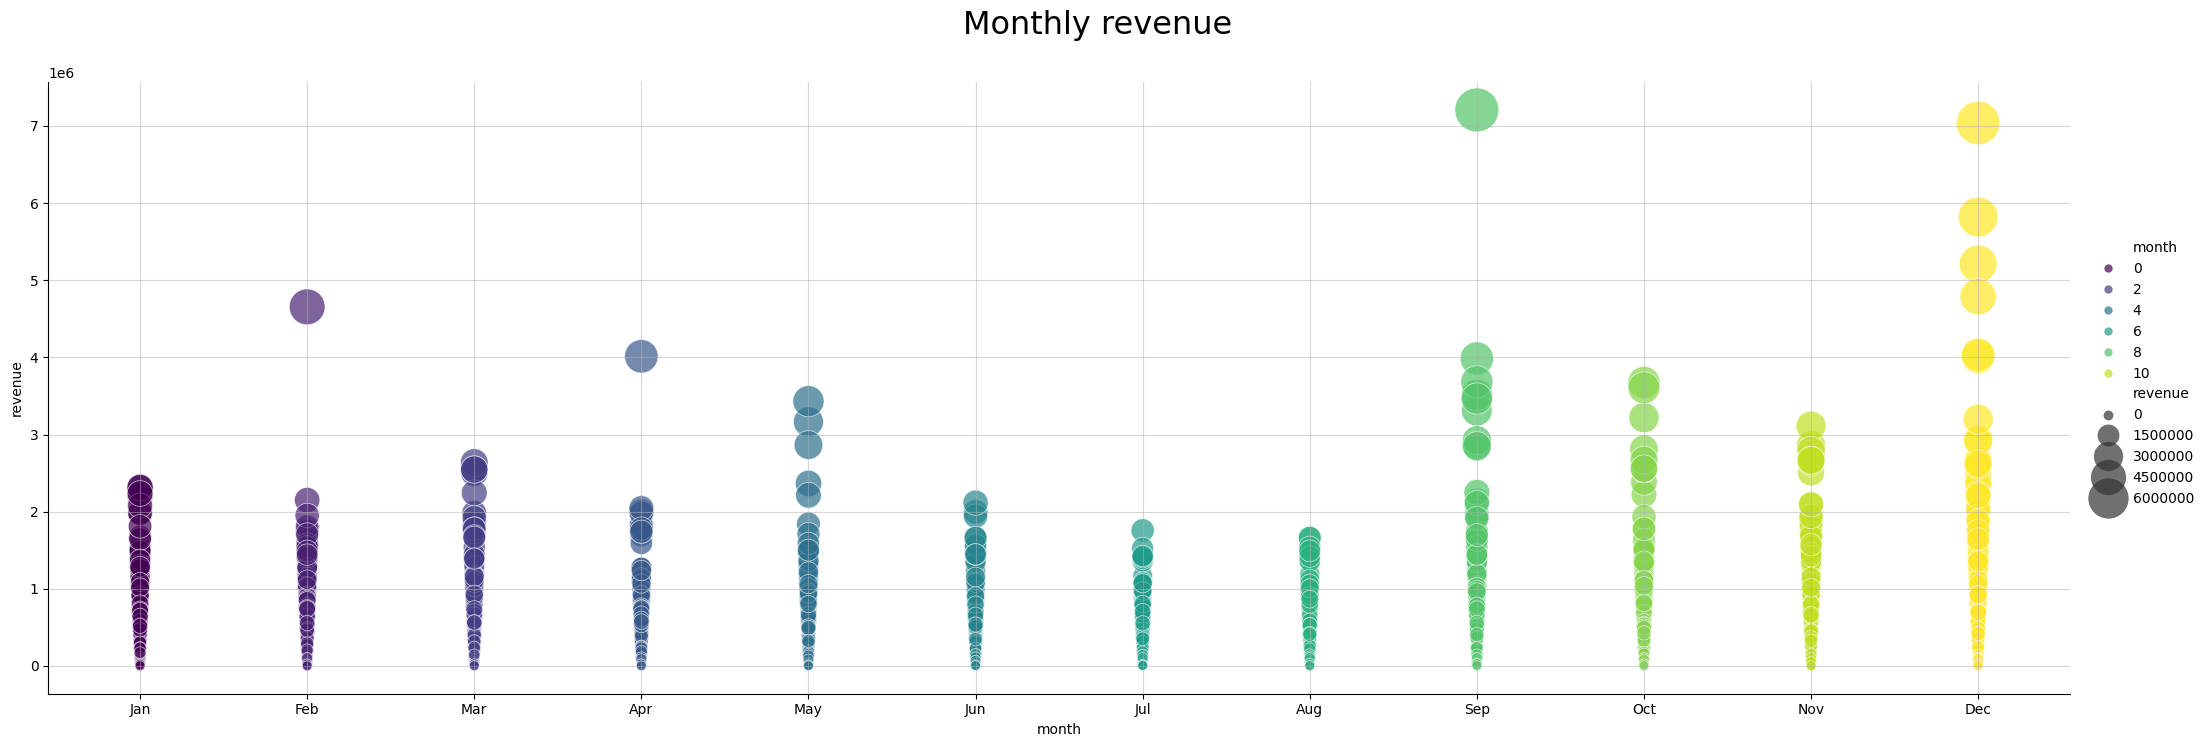

In [47]:
g = sns.relplot(
    data=gp_revenue,
    x='month',
    y='revenue',
    size='revenue',         
    hue='month',       
    palette='viridis',      
    sizes=(50, 1000),       
    alpha=0.7,              
    aspect=3,
    height=7,  
)
g.set(xticks=range(12), xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
g.figure.suptitle('Monthly revenue', y=1.06, fontsize=23);
plt.grid(True, alpha=0.5) 

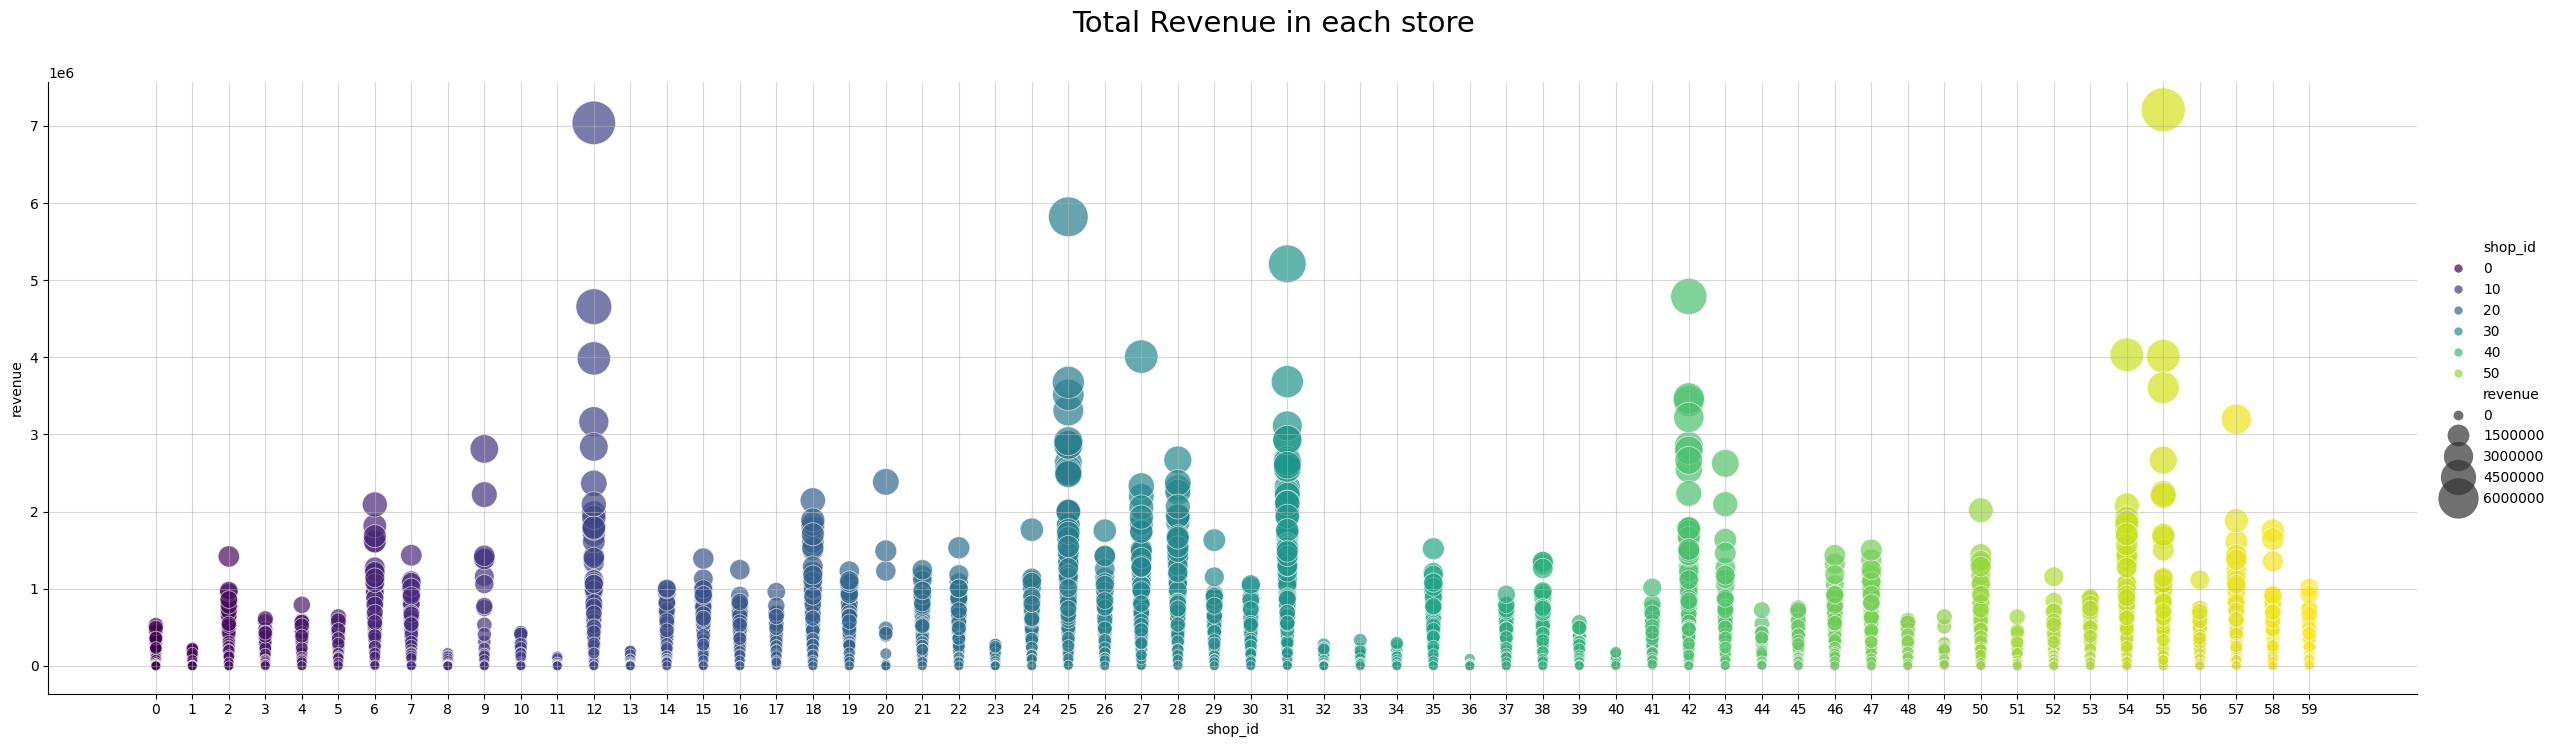

In [48]:
g = sns.relplot(
    data=gp_revenue,
    x='shop_id',
    y='revenue',
    size='revenue',         
    hue='shop_id',       
    palette='viridis',      
    sizes=(50, 1000),       
    alpha=0.7,              
    aspect=3.5,
    height=7,  
)
g.set(xticks=range(60))
g.figure.suptitle('Total Revenue in each store', y=1.06, fontsize=21);
plt.grid(True, alpha=0.5)

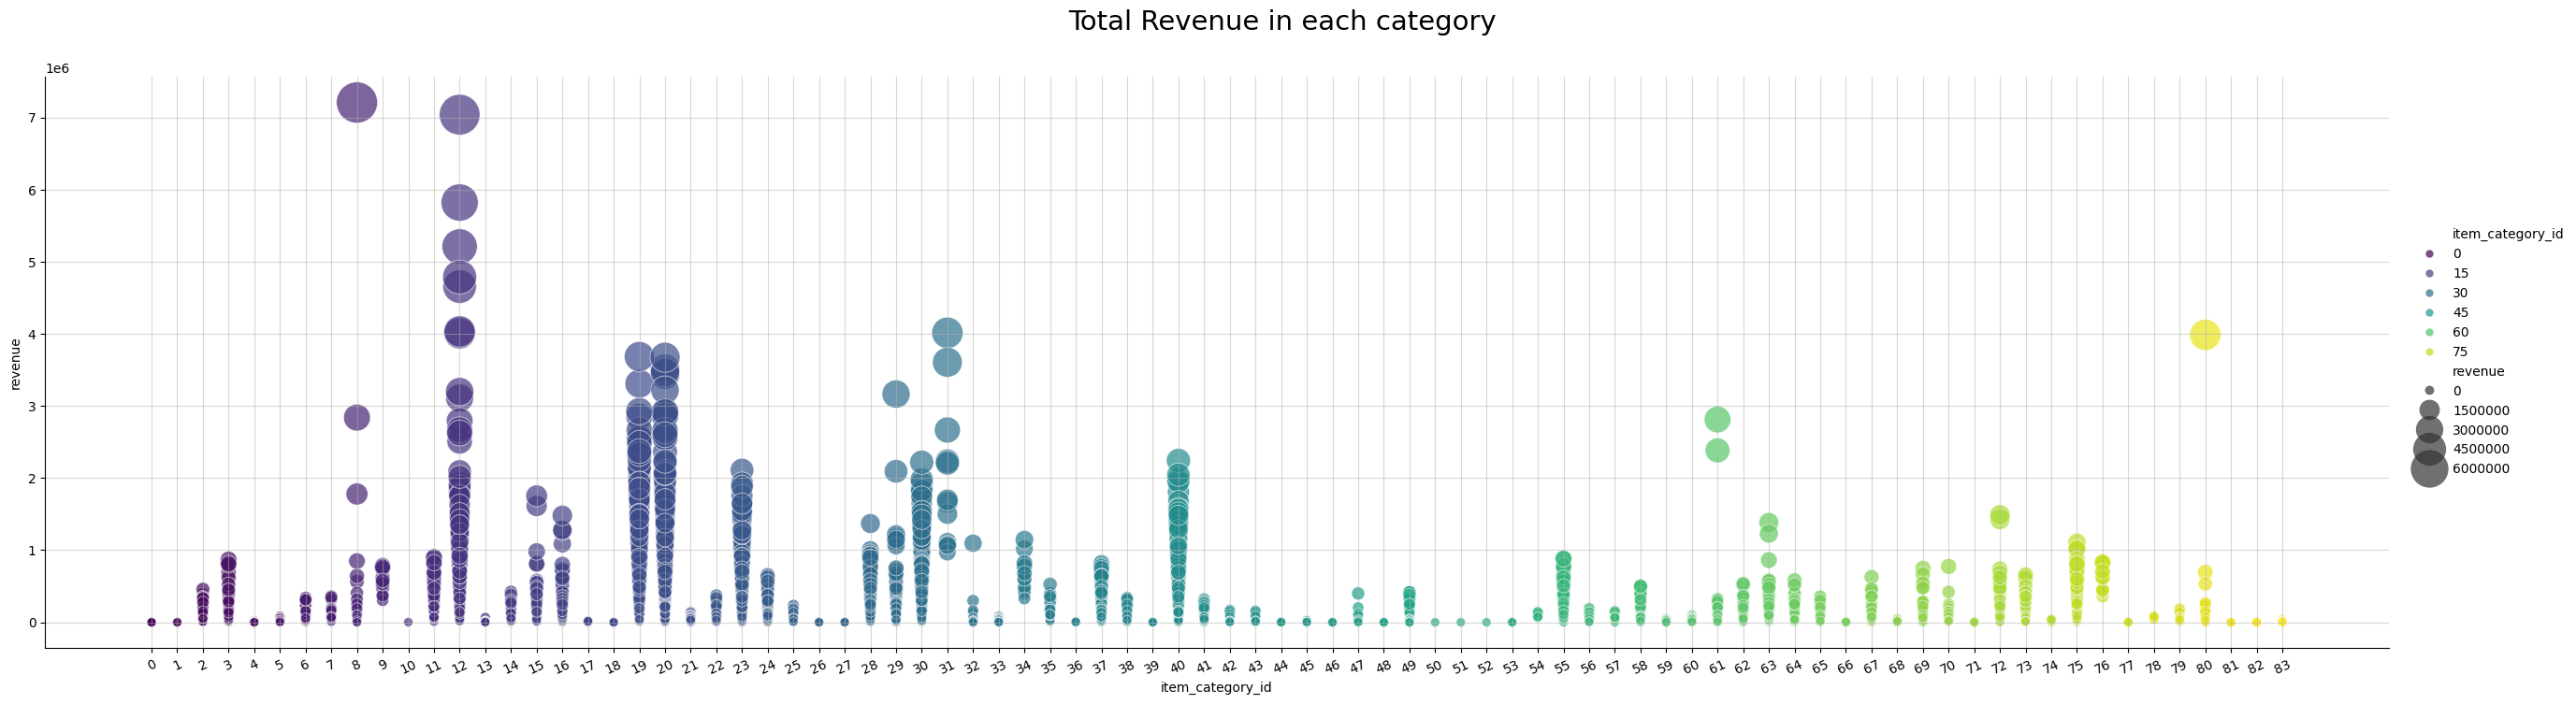

In [49]:
g = sns.relplot(
    data=gp_revenue,
    x='item_category_id',
    y='revenue',
    size='revenue',         
    hue='item_category_id',       
    palette='viridis',      
    sizes=(50, 1000),       
    alpha=0.7,              
    aspect=3.7,
    height=7,  
)
g.set(xticks=range(84), )
plt.grid(True, alpha=0.5)
g.set_xticklabels(rotation=25);
g.figure.suptitle('Total Revenue in each category', y=1.06, fontsize=21);

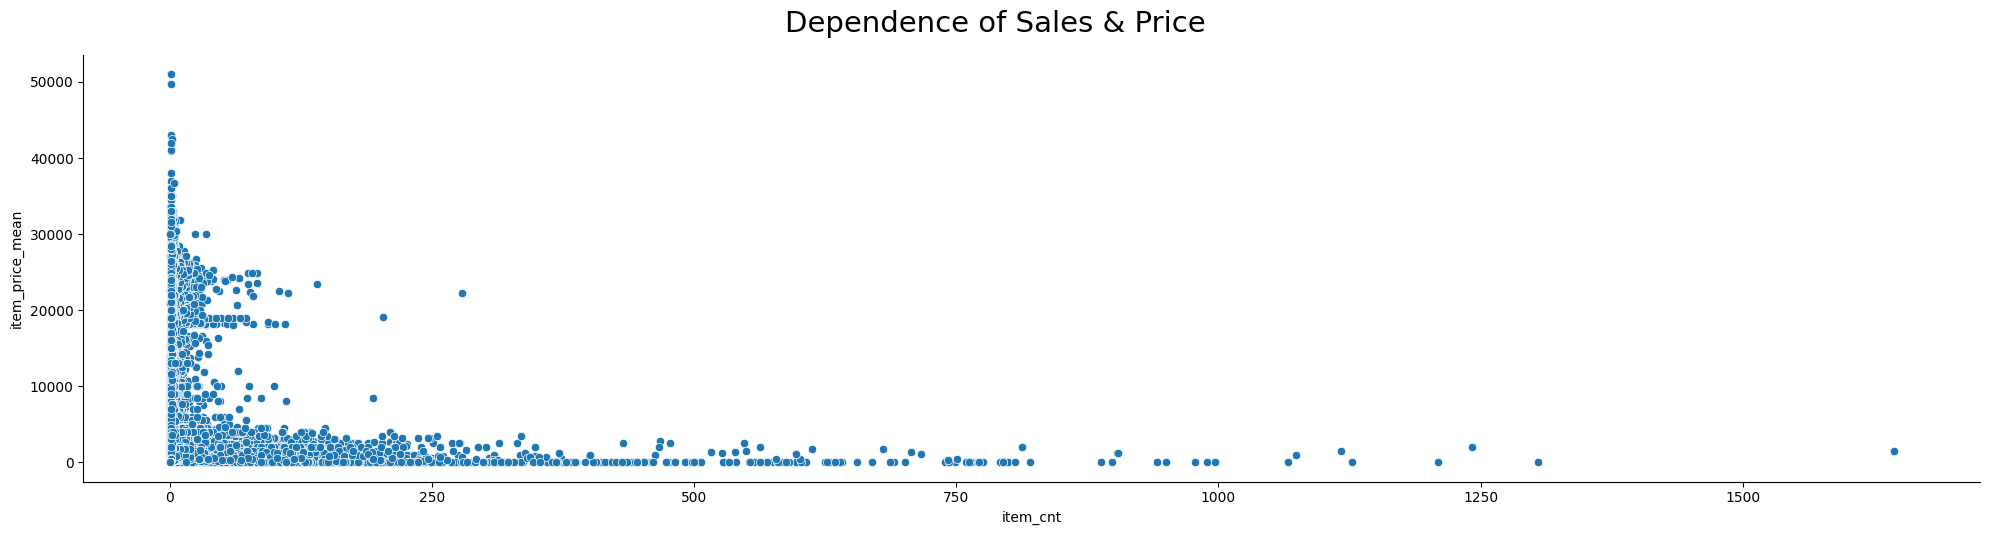

In [50]:
g = sns.relplot(
    data=train_monthly,
    x='item_cnt',
    y='item_price_mean',
    aspect=4,
    kind='scatter',
    marker='o'
);
g.figure.suptitle('Dependence of Sales & Price', y=1.06, fontsize=21);

In [51]:
train_monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 44484240 entries, 0 to 44484239
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   date_block_num         int64  
 1   shop_id                int64  
 2   item_id                int64  
 3   item_category_id       float64
 4   item_cnt               float64
 5   transaction            float64
 6   item_cnt_mean          float64
 7   item_price_mean        float64
 8   revenue                float64
 9   season                 str    
 10  year                   int64  
 11  month                  int64  
 12  items_per_transaction  float64
dtypes: float64(7), int64(5), str(1)
memory usage: 4.3 GB


In [78]:
gp_items_per_transaction= train_monthly.groupby(['month', 'shop_id', 'item_category_id'], as_index=False).agg({
                                                                    'item_cnt': 'sum',
                                                                    'item_price_mean': 'mean',
                                                                    'revenue': 'sum',
                                                                    'items_per_transaction':'sum'
                                                                                                                   
                                                                     })

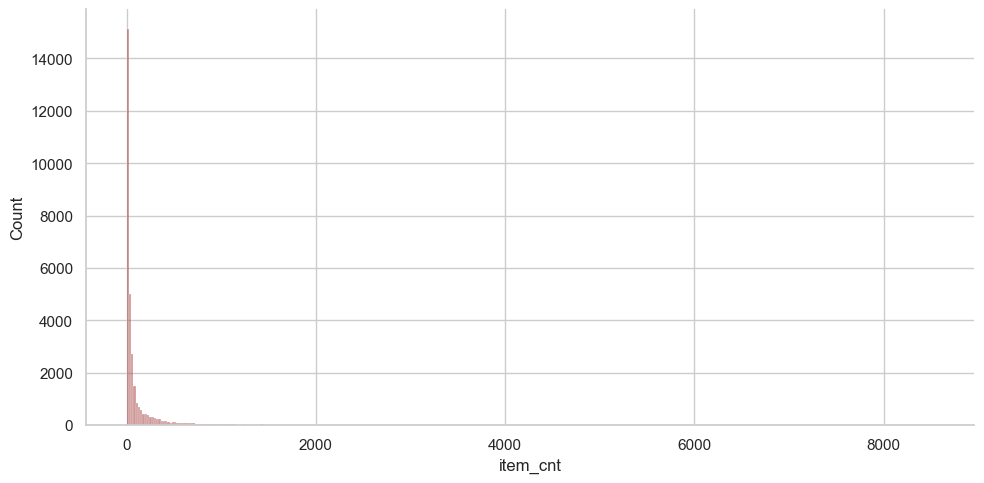

In [79]:
g = sns.displot(
    data = gp_items_per_transaction,
    x = 'item_cnt',
    aspect=2,
    color='darkred',
    kind="hist", 
    alpha=0.4,
    
)

In [80]:
sales_data = gp_items_per_transaction[gp_items_per_transaction['item_cnt'] <= 200]

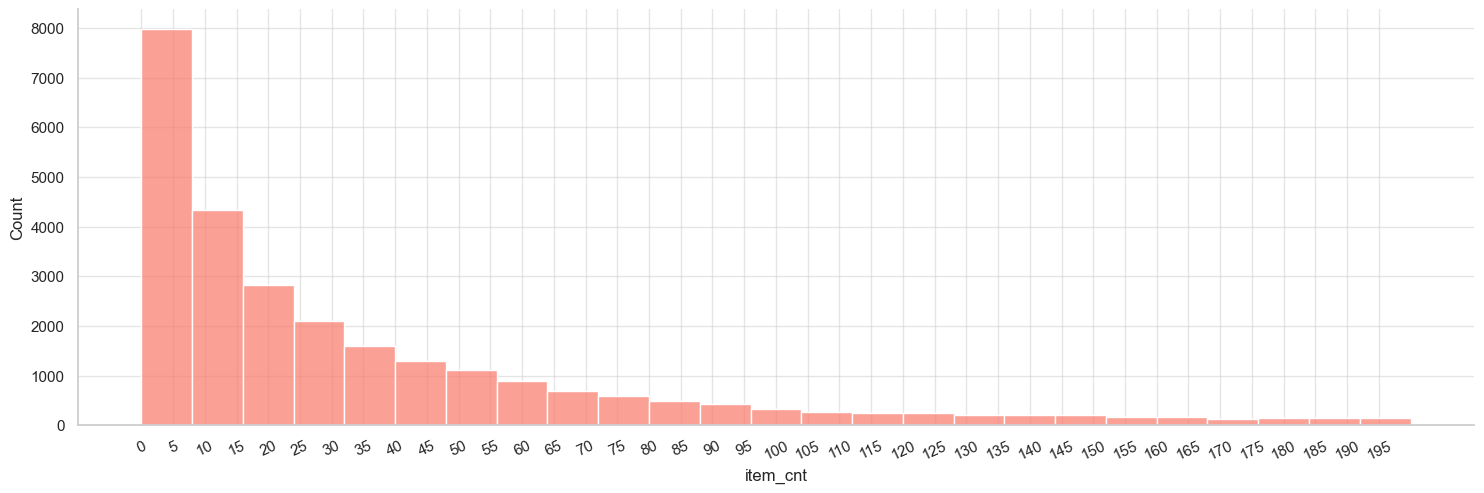

In [81]:
g = sns.displot(
    data=sales_data,
    x='item_cnt',
    color='salmon',
    aspect=3,
    kind='hist', 
    bins=25,
)
g.set(xticks=range(200), )
plt.grid(True, alpha=0.5)
g.set_xticklabels(rotation=25, step=5);
# g.figure.suptitle('Total Revenue in each category', y=1.06, fontsize=21);

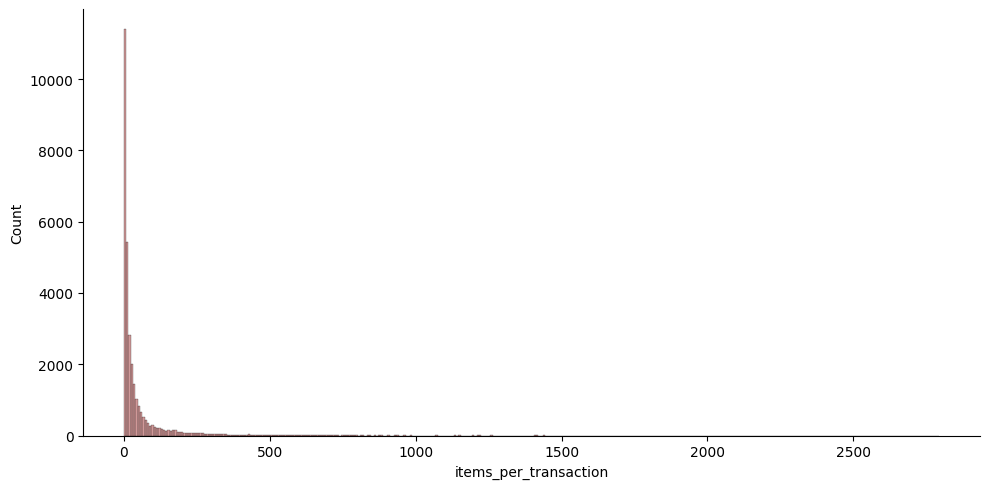

In [56]:
g = sns.displot(
    data = gp_items_per_transaction,
    x = 'items_per_transaction',
    aspect=2,
    color='darkred',
    kind="hist", 
    alpha=0.4,
    
)

In [57]:
gp_items_per_transaction['items_per_transaction'].sort_values(ascending=False)

6898     2794.629545
1473     2691.285362
4277     2636.444245
9539     2572.309878
12134    2432.058638
            ...     
10241       0.000000
24334       0.000000
27428       0.000000
15721       0.000000
0           0.000000
Name: items_per_transaction, Length: 31516, dtype: float64

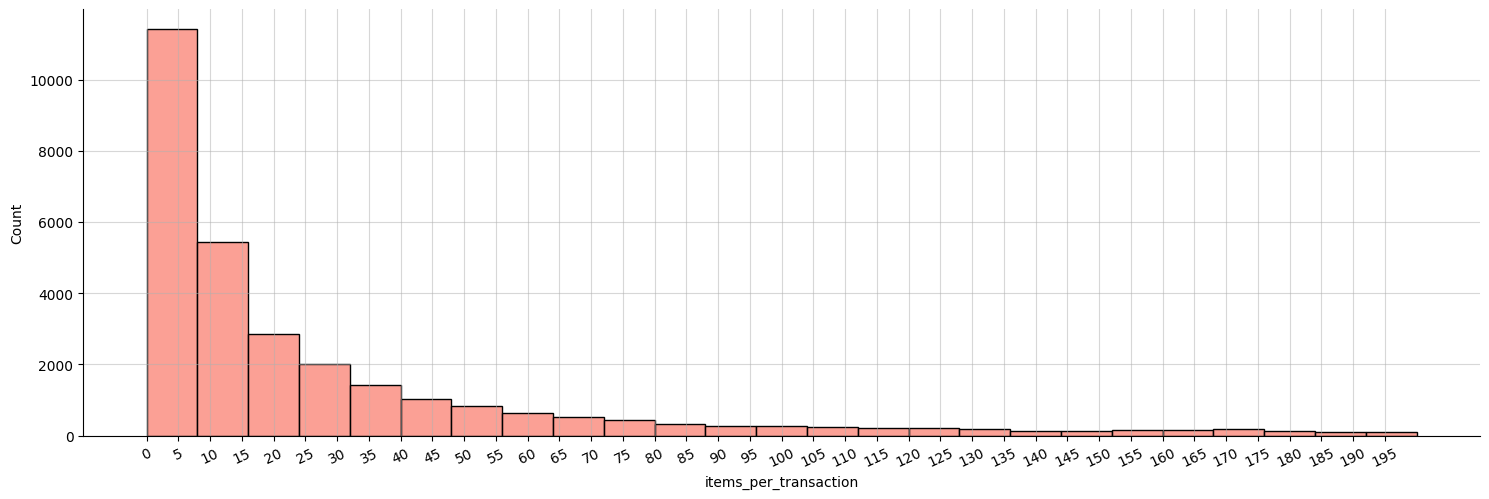

In [58]:
sales_data = gp_items_per_transaction[gp_items_per_transaction['items_per_transaction'] <= 200]
g = sns.displot(
    data=sales_data,
    x='items_per_transaction',
    color='salmon',
    aspect=3,
    kind='hist', 
    bins=25,
)
g.set(xticks=range(200), )
plt.grid(True, alpha=0.5)
g.set_xticklabels(rotation=25, step=5);
# g.figure.suptitle('Total Revenue in each category', y=1.06, fontsize=21);

---

In [70]:
sales_data_0_to_20 = train_monthly[(train_monthly['item_cnt'] >= 0) & (train_monthly['item_cnt'] <= 20 )]['item_cnt']

In [71]:
sales_data_after_20 = train_monthly[train_monthly['item_cnt'] > 20 ]['item_cnt']

## Процент данных о продажи вещи более 20 штук = 0.025800059299212467 %

In [72]:
len(sales_data_after_20) / len(sales_data_0_to_20) * 100

0.025800059299212467

---

## FE: (Добавляем Лаги для продаж товаров и цены, добавляем тренд продаж товаров, цену за штуку в среднем, рост/ снижение цены, есть ли праздники в месяце, сколько выходных в месяце, с какого дня месяц начинается , разбили магазины и категории по бинам(по "популярности"))

In [73]:
lag_cols = ['date_block_num', 'shop_id', 'item_id', 'item_cnt']

for lag in [1, 2, 3]:

    lag_df = train_monthly[lag_cols].copy()
    

    lag_df['date_block_num'] = lag_df['date_block_num'] + lag
    

    lag_col_name = f'item_cnt_lag_{lag}'
    lag_df = lag_df.rename(columns={'item_cnt': lag_col_name})
    

    train_monthly = pd.merge(train_monthly, lag_df, on=['date_block_num', 'shop_id', 'item_id'], how='left')
    train_monthly[lag_col_name] = train_monthly[lag_col_name].fillna(0)

train_monthly['avg_past_3_months'] = (train_monthly['item_cnt_lag_1'] + train_monthly['item_cnt_lag_2'] + train_monthly['item_cnt_lag_3']) / 3

train_monthly['item_trend'] = train_monthly['item_cnt_lag_1'] - train_monthly['avg_past_3_months']
train_monthly = train_monthly.drop(columns=['avg_past_3_months'])

In [84]:
train_monthly.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
date_block_num,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
shop_id,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59
item_id,22154,2552,2554,2555,2564,2565,2572,2573,2574,2593,2604,2607,2609,2548,2611,2546,2515,2705,2715,2716
item_category_id,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,0.0
item_cnt,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
transaction,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
item_cnt_mean,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
item_price_mean,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1799.0,0.0,0.0
revenue,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,798.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1799.0,0.0,0.0
season,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter


In [85]:
train_monthly['item_price_per_unit'] = train_monthly['revenue'] / train_monthly['item_cnt'].replace(0, 1)

In [86]:
train_monthly['item_price_per_unit'] = train_monthly['item_price_per_unit'].fillna(0)

In [87]:
lag_price = train_monthly[['date_block_num', 'shop_id', 'item_id', 'item_price_per_unit']].copy()
lag_price['date_block_num'] = lag_price['date_block_num'] + 1
lag_price = lag_price.rename(columns={'item_price_per_unit': 'price_lag_1'})


train_monthly = pd.merge(train_monthly, lag_price, on=['date_block_num', 'shop_id', 'item_id'], how='left')
train_monthly['price_lag_1'] = train_monthly['price_lag_1'].fillna(0)


train_monthly['price_diff'] = train_monthly['item_price_per_unit'] - train_monthly['price_lag_1']

train_monthly['price_increase'] = ((train_monthly['price_diff'] > 0) & (train_monthly['price_lag_1'] > 0)).astype(int)
train_monthly['price_decrease'] = ((train_monthly['price_diff'] < 0) & (train_monthly['price_lag_1'] > 0)).astype(int)

train_monthly = train_monthly.drop(columns=['price_diff', 'price_lag_1'])

In [88]:
calendar_df = pd.DataFrame({'date_block_num': range(35)})
calendar_df['real_date'] = pd.date_range(start='2013-01-01', periods=35, freq='MS')
calendar_df['month_num'] = calendar_df['real_date'].dt.month

In [89]:
holiday_months = [1, 2, 3, 5, 6, 11, 12] 
calendar_df['has_holiday'] = calendar_df['month_num'].isin(holiday_months).astype(int)

In [90]:
def get_weekend_count(date_obj):
    year, month = date_obj.year, date_obj.month
    _, num_days = calendar.monthrange(year, month)

    return sum(1 for day in range(1, num_days + 1) if calendar.weekday(year, month, day) >= 5)


In [91]:
calendar_df['weekend_count'] = calendar_df['real_date'].apply(get_weekend_count)

In [92]:
calendar_df['month_start_weekday'] = calendar_df['real_date'].dt.weekday

In [93]:
calendar_df = calendar_df.drop(columns=['real_date', 'month_num'])

In [94]:
train_monthly = pd.merge(train_monthly, calendar_df, on='date_block_num', how='left')

In [95]:
train_monthly.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
date_block_num,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
shop_id,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59
item_id,22154,2552,2554,2555,2564,2565,2572,2573,2574,2593,2604,2607,2609,2548,2611,2546,2515,2705,2715,2716
item_category_id,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,0.0
item_cnt,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
transaction,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
item_cnt_mean,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
item_price_mean,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1799.0,0.0,0.0
revenue,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,798.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1799.0,0.0,0.0
season,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter


In [97]:
shop_sales = train_monthly.groupby('shop_id')['item_cnt'].sum().reset_index()

In [98]:
shop_sales['shop_tier'] = pd.qcut(shop_sales['item_cnt'], q=3, labels=['Low', 'Mid', 'Top'])

shop_sales = shop_sales.drop(columns=['item_cnt'])

In [99]:
cat_sales = train_monthly.groupby('item_category_id')['item_cnt'].sum().reset_index()

In [100]:
cat_sales['category_tier'] = pd.qcut(cat_sales['item_cnt'], q=3, labels=['Low', 'Mid', 'Top'])
cat_sales = cat_sales.drop(columns=['item_cnt'])

In [101]:
train_monthly = pd.merge(train_monthly, shop_sales, on='shop_id', how='left')
train_monthly = pd.merge(train_monthly, cat_sales, on='item_category_id', how='left')

In [102]:
train_monthly['shop_tier'] = train_monthly['shop_tier'].fillna("Mid")
train_monthly['category_tier'] = train_monthly['category_tier'].fillna("Mid")

In [104]:
train_monthly.head(40).T

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
date_block_num,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
shop_id,59,59,59,59,59,59,59,59,59,59,...,59,59,59,59,59,59,59,59,59,59
item_id,22154,2552,2554,2555,2564,2565,2572,2573,2574,2593,...,2833,2835,2836,2844,2845,2847,2848,2854,2857,2920
item_category_id,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,0.0,...,30.0,0.0,0.0,0.0,0.0,23.0,30.0,30.0,0.0,21.0
item_cnt,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,0.0,3.0
transaction,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,3.0
item_cnt_mean,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.5,0.0,1.0
item_price_mean,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,399.0,0.0,...,599.0,0.0,0.0,0.0,0.0,1699.0,99.0,449.0,0.0,598.833333
revenue,999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,798.0,0.0,...,599.0,0.0,0.0,0.0,0.0,3398.0,198.0,1347.0,0.0,1796.5
season,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,...,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter,Winter


---